In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Анализ временного ряда

In [2]:
df = pd.read_csv(r"C:\Users\Tysyachnyj V\Desktop\Предиктивная аналитика\retail_sales_mock_data.csv", parse_dates=True, index_col="Date")
df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

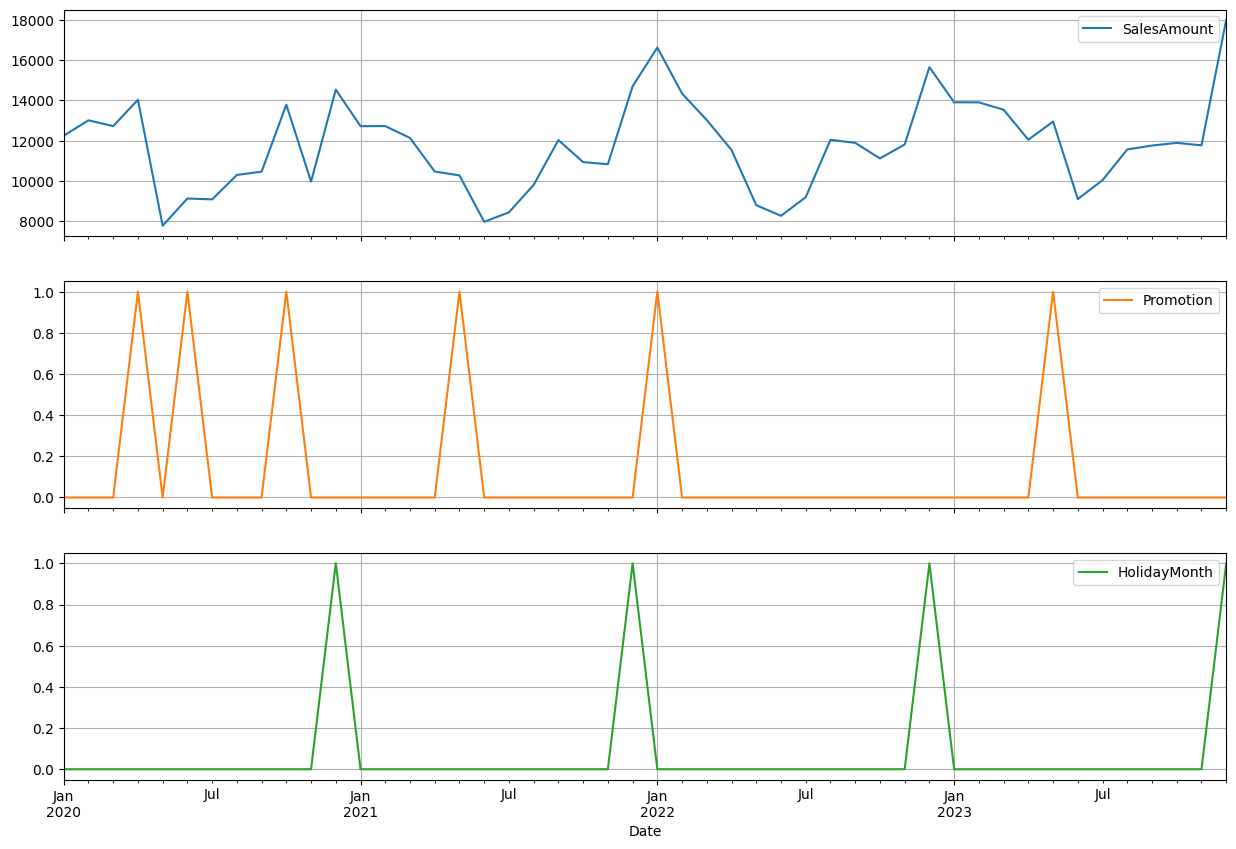

In [3]:
df.plot(subplots=True, figsize=(15,10), grid=True)

Text(0.5, 1.0, 'Ящики с усами по годам')

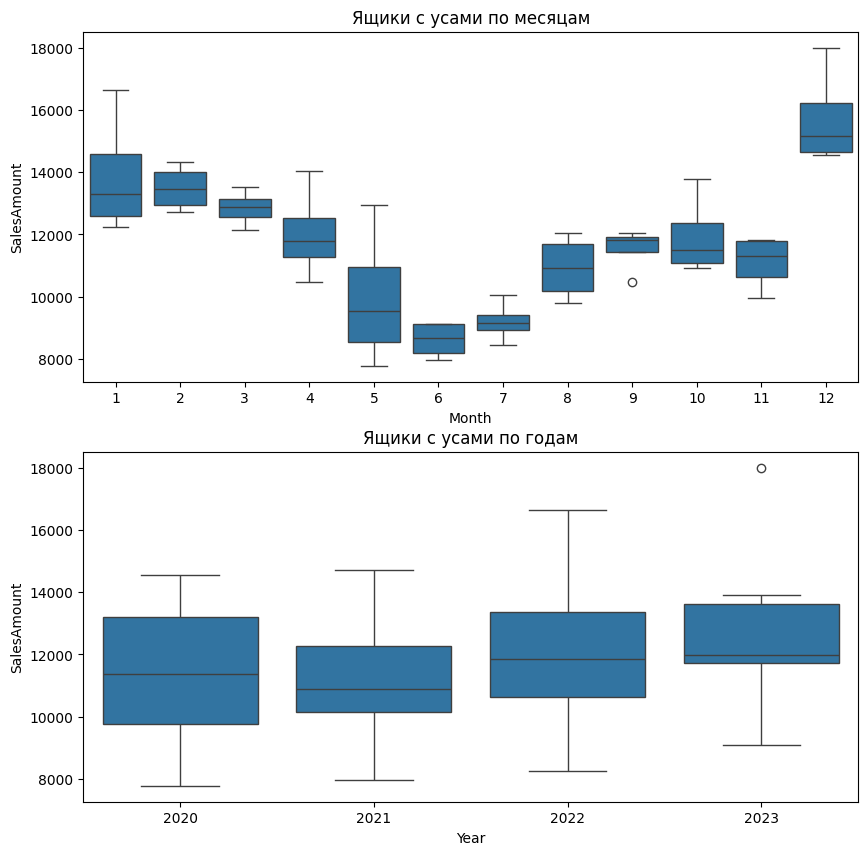

In [4]:
df['Month'] = df.index.month
df['Year'] = df.index.year
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
sns.boxplot(df, x='Month', y="SalesAmount", ax=axes[0])
axes[0].set_title("Ящики с усами по месяцам")
sns.boxplot(df, x='Year', y="SalesAmount", ax=axes[1])
axes[1].set_title("Ящики с усами по годам")

Данные представляют собой выручку по месяцам с 2020 по 2023 год с отметками о проведении акций и праздничном месяце, которым является декабрь (в связи с праздниками и окончанием года продажи выше).

Судя по построенным боксплотам, в данных присутвует сезонный тренд (летом просадка, а зимой значительный рост). Также по годовому графике можно сказать, что в среднем доходность за год повышается, но не так так сильно, если смотреть медиану, но при этом крайние значения по годам показывают стабильный рост.

В некоторые месяца наблюдается сильно больший разброс значений, что, наверное, можно объяснить небольшой выборкой (в 4 года) и разными экономическими нестабильными факторами.

In [5]:
import calendar

df['Усреденные_доходы'] = df['SalesAmount'].rolling(window=3).mean()

all_month_year_df = pd.pivot_table(df, values="SalesAmount",
                                   index=["Month"],
                                   columns=["Year"],
                                   fill_value=0)

month_index = [month for month in calendar.month_abbr if month]

all_month_year_df = all_month_year_df.set_index([month_index])

all_month_year_df

Year,2020,2021,2022,2023
Jan,12248.0,12720.0,16623.0,13904.0
Feb,13011.0,12724.0,14336.0,13901.0
Mar,12722.0,12136.0,13023.0,13534.0
Apr,14030.0,10468.0,11537.0,12048.0
May,7783.0,10279.0,8800.0,12949.0
Jun,9131.0,7976.0,8273.0,9104.0
Jul,9089.0,8445.0,9199.0,10042.0
Aug,10300.0,9810.0,12043.0,11566.0
Sep,10464.0,12031.0,11892.0,11759.0
Oct,13786.0,10937.0,11121.0,11890.0


Text(0.5, 1.0, 'Sales amount')

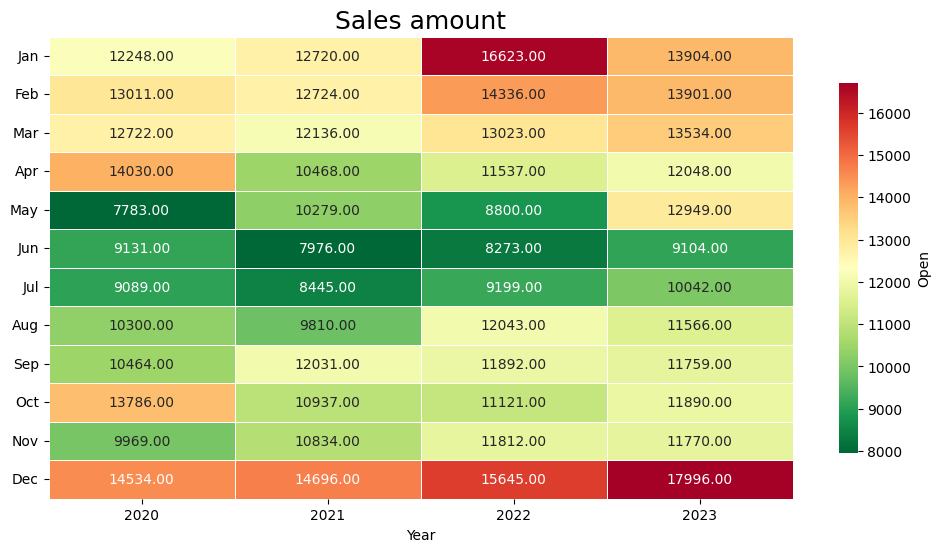

In [6]:
fig, ax = plt.subplots(figsize=(12,6))
ax = sns.heatmap(all_month_year_df, cmap='RdYlGn_r', robust=True,
                 fmt='.2f', annot=True, linewidths=.5, ax=ax,
                 cbar_kws={'shrink':.8, 'label':'Open'})

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.title('Sales amount', fontdict={'fontsize':18})

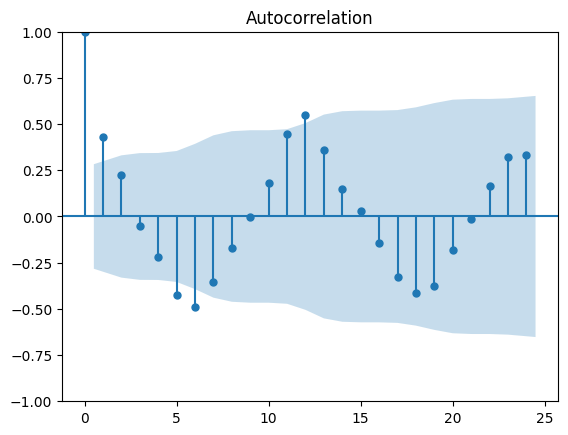

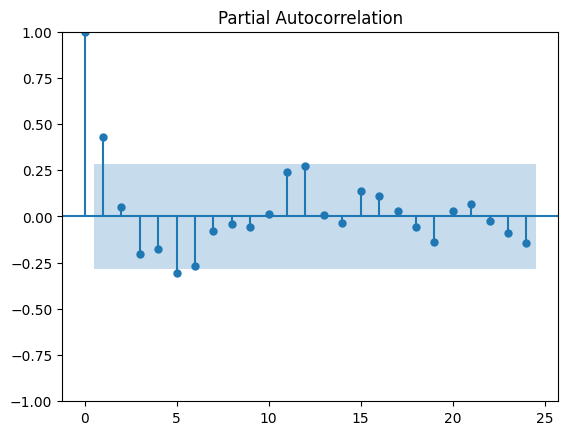

In [7]:
# для сравнения график ACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig1 = plot_acf(df['SalesAmount'], lags=24)
fig2 = plot_pacf(df['SalesAmount'], lags=24)
plt.show()

Графики автокорреляций подтверждают наличие сезонного тренда: график достаточно плавно синусоидально затихает, при этом есть положительная корреляция на годовых циклах, и отрицательная на полугодовых. Также график частичной автокорреляции показывает, что наибольшее влияние имеет только предыдущий месяц и тот, что был 5 месяцев назад, остальные уже не выходят за пределы доверительного интеравала.

In [8]:
from statsmodels.tsa.stattools import adfuller, kpss

dftest = adfuller(df['SalesAmount'], autolag="AIC")
print(f"Тест Дики-Фуллера: {dftest[1]}")

kpsstest = kpss(df['SalesAmount'], regression="c", nlags="auto")
print(f"KPSS-тест: {kpsstest[1]}")

Тест Дики-Фуллера: 0.0001853558643026136
KPSS-тест: 0.1


C:\Users\Tysyachnyj V\AppData\Local\Temp\ipykernel_15128\3237079104.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  dftest = adfuller(df['SalesAmount'], autolag="AIC")
C:\Users\Tysyachnyj V\AppData\Local\Temp\ipykernel_15128\3237079104.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpsstest = kpss(df['SalesAmount'], regression="c", nlags="auto")
C:\Users\Tysyachnyj V\AppData\Local\Temp\ipykernel_15128\3237079104.py:6: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `l

Тесты Дики-Фуллера и KPSS дали соглассованный результат: в первом тесте нулевая гипотеза (нестационарность) не принимается, а во втором (стационарность) - принимается. 

Таким образом, можно сделать вывод, что данный ряд стационарен, но имееет достаточно сильную сезонность.

# Аддитивная декомпозиция

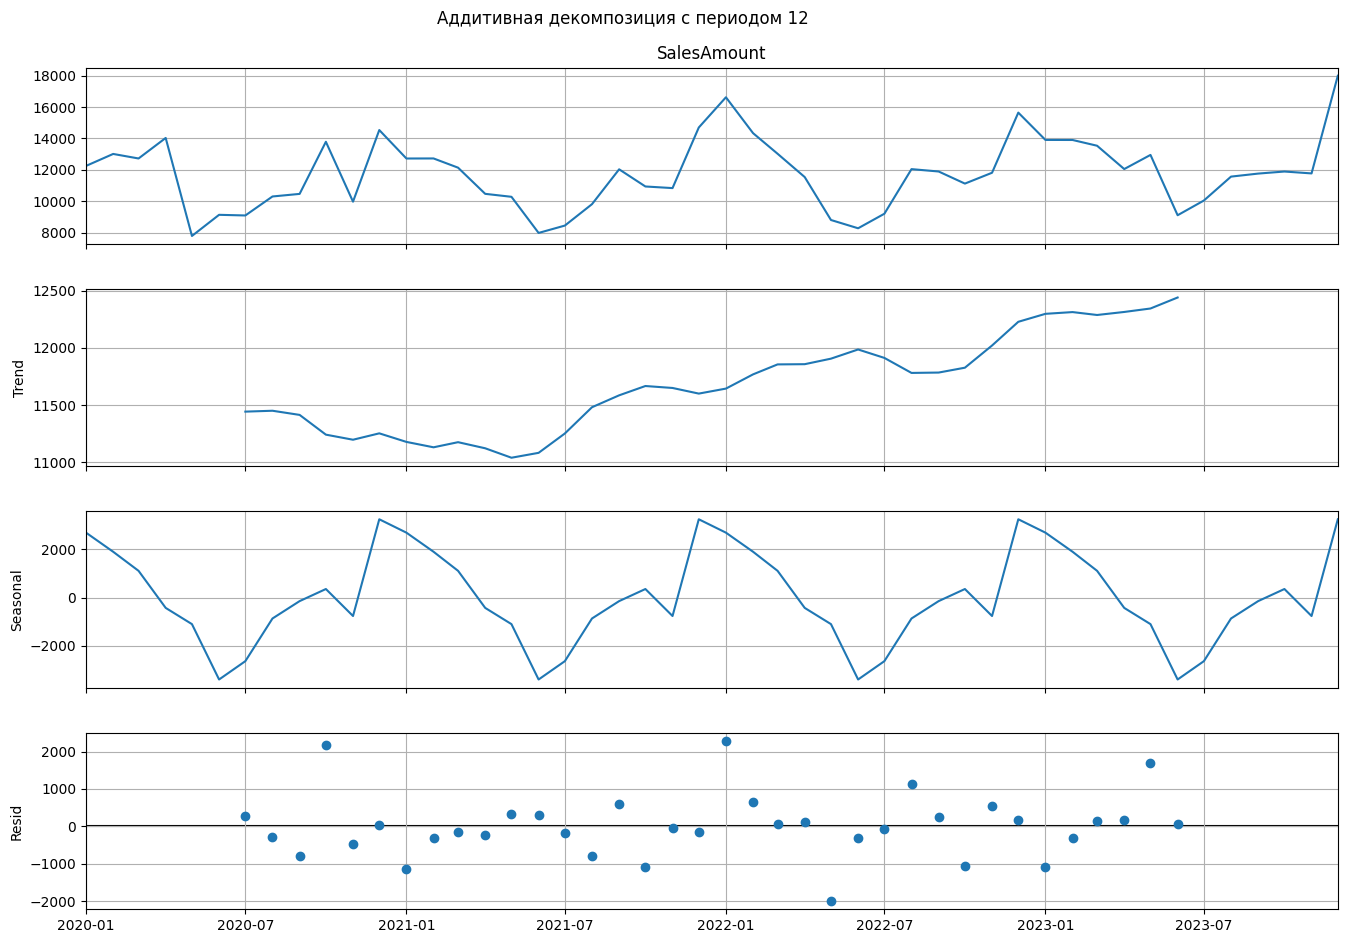

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['SalesAmount'], model='additive', period=12)

fig = result.plot()

for ax in fig.axes:
    ax.figure.set_size_inches(15, 10)
    ax.grid()

plt.suptitle("Аддитивная декомпозиция с периодом 12")
plt.show()

# Мультипликативная декомпозиция

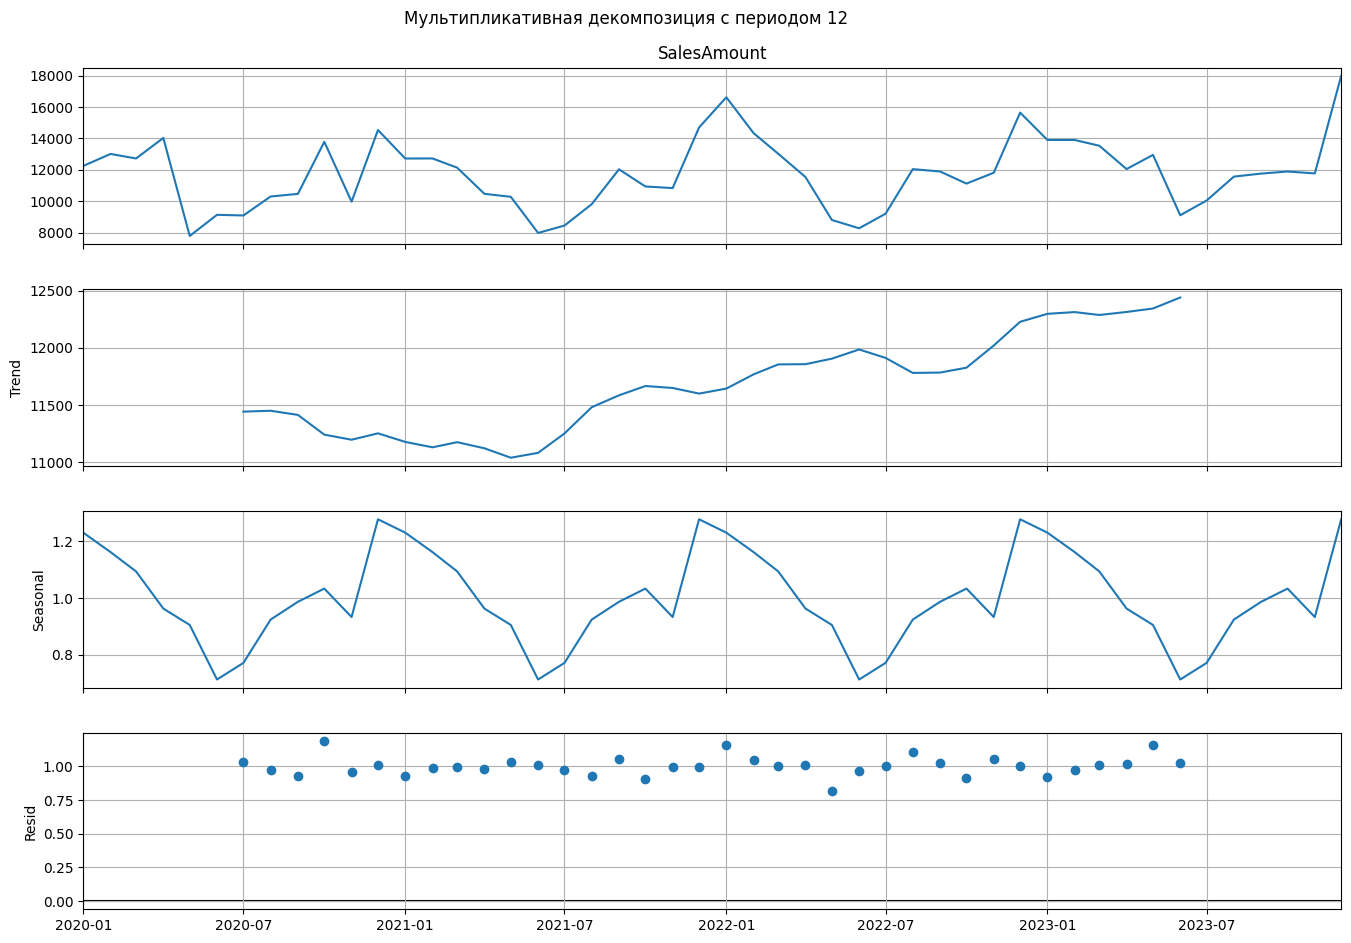

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['SalesAmount'], model='multiplicative', period=12)

fig = result.plot()

for ax in fig.axes:
    ax.figure.set_size_inches(15, 10)
    ax.grid()

plt.suptitle("Мультипликативная декомпозиция с периодом 12")
plt.show()

# STL декомпозиция

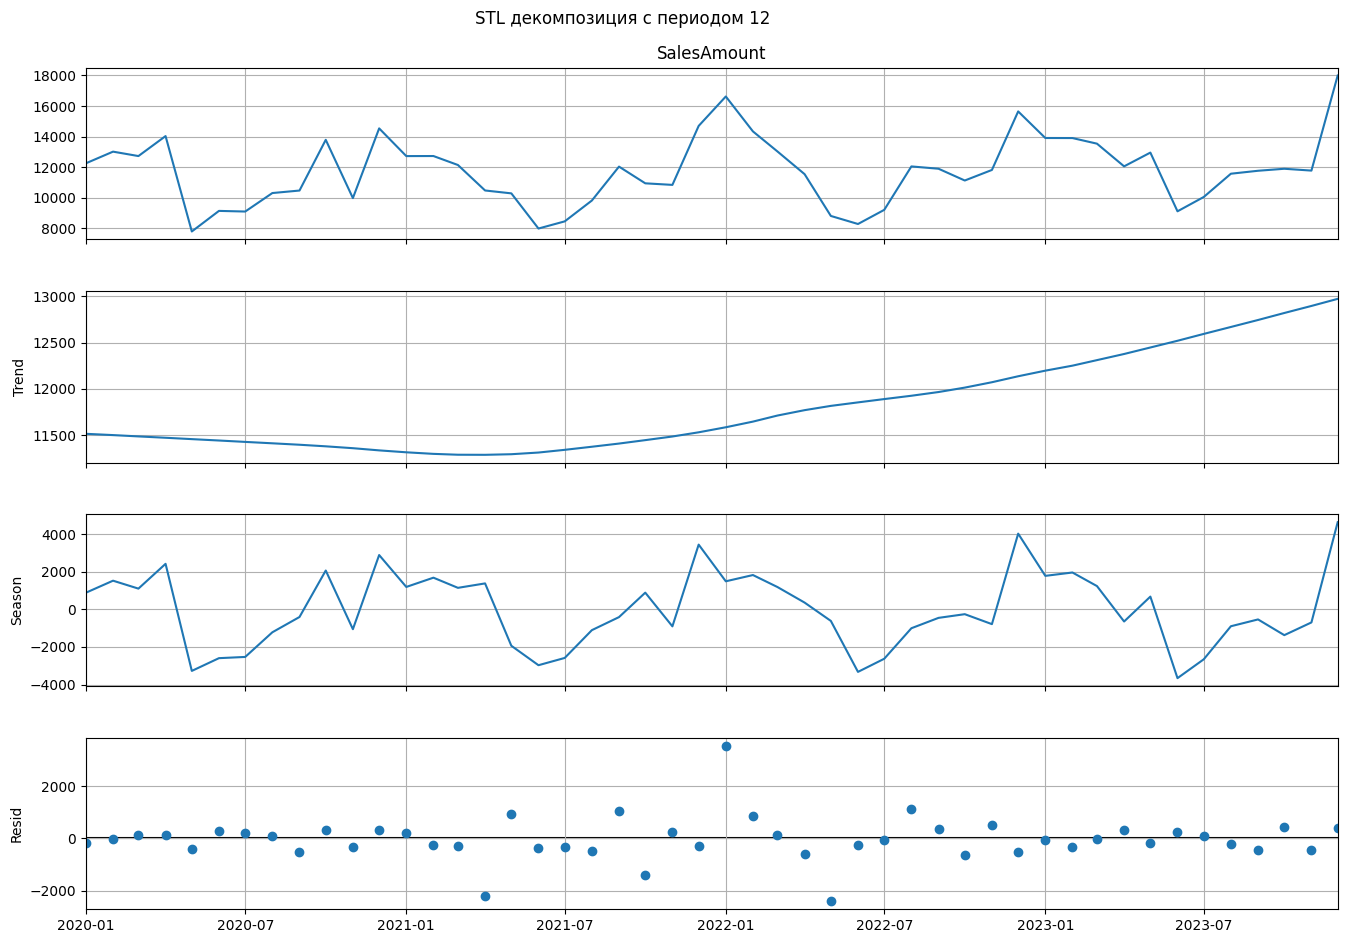

In [11]:
from statsmodels.tsa.seasonal import STL

stl = STL(df['SalesAmount'], period=12, seasonal=13, robust=True)
result = stl.fit()

fig = result.plot()

for ax in fig.axes:
    ax.figure.set_size_inches(15, 10)
    ax.grid()

plt.suptitle("STL декомпозиция с периодом 12")
plt.show()

# Спектральный анализ

In [12]:
from scipy.fft import fft, fftfreq

dt = 1
n = len(df['SalesAmount'])

# FFT
fft_vals = fft(df['SalesAmount'])
freqs = fftfreq(n, dt)

# Берём только положительные частоты
power = np.abs(fft_vals[:n//2])
freqs_pos = freqs[:n//2]

# Переводим частоту в период (дни)
periods = 1 / freqs_pos[1:]
power_pos = power[1:]

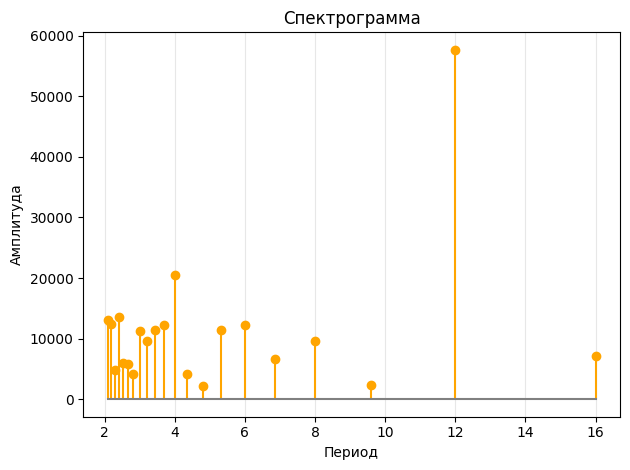

In [13]:
mask = (periods >= 2) & (periods <= 16)
plt.stem(periods[mask], power_pos[mask], linefmt='orange', markerfmt='o', basefmt='gray')
plt.xlabel('Период')
plt.ylabel('Амплитуда')
plt.title('Спектрограмма')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Вейвлет анализ

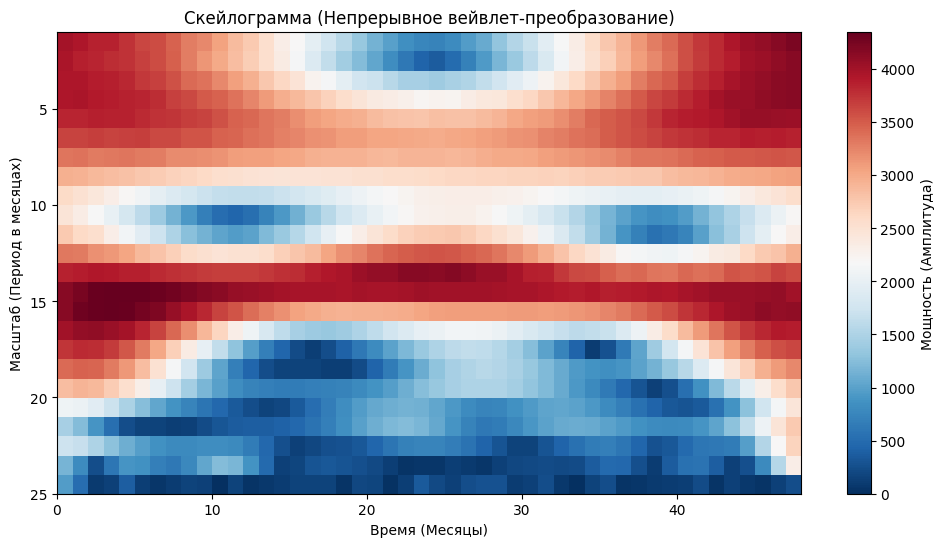

In [14]:
import pywt

# 1. Определяем масштабы (scales). 
# Так как у нас 48 месяцев и период сезонности = 12, 
# масштабы от 1 до 32 покрывают короткие и годовые циклы.
scales = np.arange(1, 25)

coefficients, frequencies = pywt.cwt(df['SalesAmount'], scales, 'cmor1.5-1.0', sampling_period=1)

# 3. Строим скейлограмму
plt.figure(figsize=(12, 6))
# Берем модуль коэффициентов для отображения мощности
plt.imshow(np.abs(coefficients), extent=[0, len(df['SalesAmount']), 1, 25], 
           cmap='RdBu_r', aspect='auto', vmax=abs(coefficients).max(), vmin=0)

plt.colorbar(label='Мощность (Амплитуда)')
plt.ylabel('Масштаб (Период в месяцах)')
plt.xlabel('Время (Месяцы)')
plt.title('Скейлограмма (Непрерывное вейвлет-преобразование)')
plt.gca().invert_yaxis() # Инвертируем ось Y, чтобы большие периоды были внизу
plt.show()

Среди классических декомпозиций наиболее хороший результат показала STL декомпозиция, которая смогла выделить практически гладкий тренд. Аддитивная и мультипликативная оказались слишком простыми для таких достаточно сложных данных.

Спектральный анализ показал явно годовой тренд и, что интересно, квартальный тренд, но заметно слабее, остальные на одном уровне. Стационарность позволила четко определить доминирующие частоты даже без удаления тренда, который все-таки небольшой, но есть.

Вейвлет анализ показал наличие стабильных сезонных трендов с периодом 6 месяцев (полугодовой) и, что опять же интересно, сезонность в 13 и 14 месяцев (у 12 амплитуда слабее). Благодаря этому подходу можно проследить эволюцию периодов, но из-за малого количества данных слишком большое влияние краевого эффекта, из-за чего данные имеют искажения.

# ARIMA

Поскольку основная сезонность годовая, а имеются данные только за 4 года, то наиболее логичным будет три первых года дать на обучение, а последний на предсказание.

На графике PACF реально значимым был только 1 лаг, так что следует взять AR(1): p=1

Поскольку тесты показали стационарность, то дифференцирование не требуется: d=0

Судя по графику ACF можно попробовать принять MA(1): q=1

In [15]:
train_size = 36
train = df[:train_size]
test = df[train_size:]

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -323.575
Date:                Fri, 09 Oct 2026   AIC                            655.149
Time:                        02:35:55   BIC                            661.484
Sample:                    01-01-2020   HQIC                           657.360
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.151e+04    696.301     16.533      0.000    1.01e+04    1.29e+04
ar.L1          0.4770      0.525      0.909      0.364      -0.552       1.506
ma.L1          0.0219      0.508      0.043      0.9

c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppDat

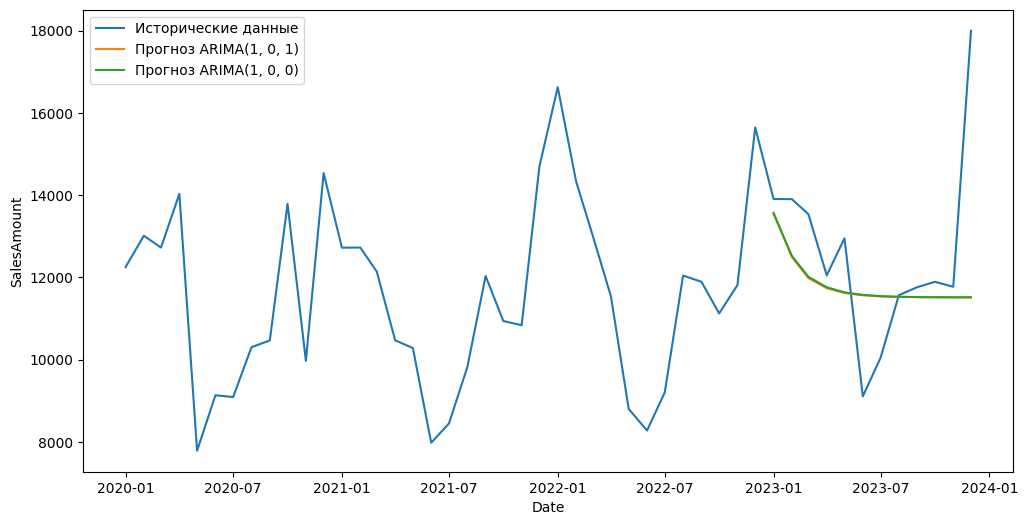

In [16]:
from statsmodels.tsa.arima.model import ARIMA

model_arima_1 = ARIMA(train['SalesAmount'], order=(1, 0, 1)).fit()
model_arima_2 = ARIMA(train['SalesAmount'], order=(1, 0, 0)).fit()
print(model_arima_1.summary())
print(model_arima_2.summary())

forecast_arima_1 = model_arima_1.get_forecast(steps=len(test['SalesAmount']))
forecast_arima_2 = model_arima_2.get_forecast(steps=len(test['SalesAmount']))
plt.figure(figsize=(12, 6))
sns.lineplot(data=df['SalesAmount'], label='Исторические данные')
sns.lineplot(data=forecast_arima_1.predicted_mean, label='Прогноз ARIMA(1, 0, 1)')
sns.lineplot(data=forecast_arima_2.predicted_mean, label='Прогноз ARIMA(1, 0, 0)')

plt.show()

In [17]:
from pmdarima import auto_arima

model = auto_arima(
    train['SalesAmount'],
    start_p=0, max_p=6,
    start_q=0, max_q=6,
    d=0,
    seasonal=False,
    trace=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=778.739, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=664.123, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=744.544, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=664.726, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=665.549, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=653.040, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=660.355, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=655.042, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=655.105, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=655.621, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=656.320, Time=0.04 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.239 seconds


Поперебирав значения и проверив на auto_arima, лучшей комбинацией оказалась (1, 0, 0)

# SARIMA

Из предыдущих рассуждений понятно, что основная сезонность - годовая: s=12

Сезонные параметры соответственно: (P, D, Q, s)=(1, 0, 0, 12)

c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  start_params = self.start_params


                                      SARIMAX Results                                      
Dep. Variable:                         SalesAmount   No. Observations:                   36
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood                -323.381
Date:                             Fri, 09 Oct 2026   AIC                            654.761
Time:                                     02:35:56   BIC                            661.095
Sample:                                 01-01-2020   HQIC                           656.972
                                      - 12-01-2022                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   5.24e-05   1.91e+04      0.000       1.000       1.000
ma.L1         -0.9994      

c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


<Axes: xlabel='Date', ylabel='SalesAmount'>

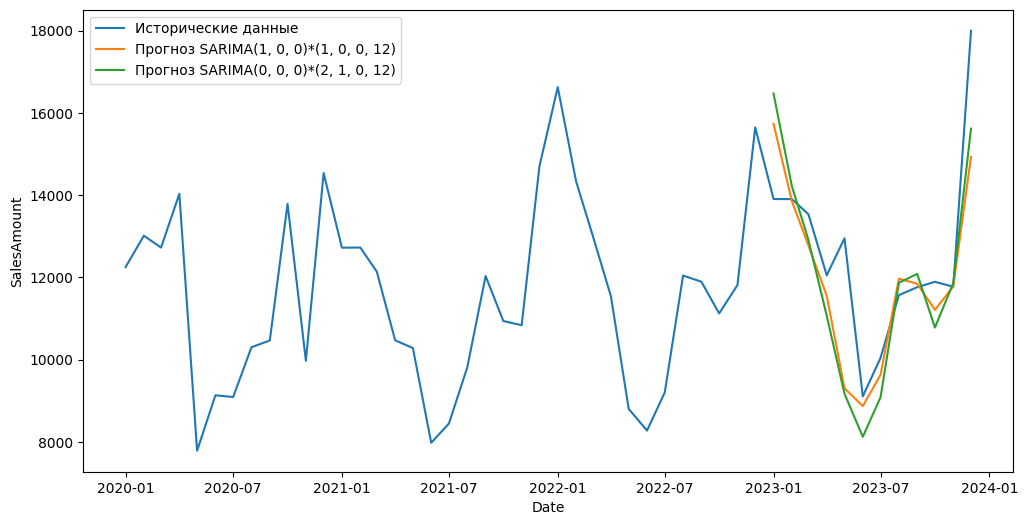

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima_1 = SARIMAX(train['SalesAmount'], 
                        order=(1, 0, 1), 
                        seasonal_order=(1, 0, 0, 12),
                        freq='MS').fit(disp=False)
model_sarima_2 = SARIMAX(train['SalesAmount'], 
                        order=(0, 0, 0), 
                        seasonal_order=(2, 1, 0, 12),
                        freq='MS').fit(disp=False)
print(model_sarima_1.summary())
print(model_sarima_2.summary())

forecast_sarima_1 = model_sarima_1.get_forecast(steps=len(test['SalesAmount']))
forecast_sarima_2 = model_sarima_2.get_forecast(steps=len(test['SalesAmount']))
plt.figure(figsize=(12, 6))
sns.lineplot(data=df['SalesAmount'], label='Исторические данные')
sns.lineplot(data=forecast_sarima_1.predicted_mean, label='Прогноз SARIMA(1, 0, 0)*(1, 0, 0, 12)')
sns.lineplot(data=forecast_sarima_2.predicted_mean, label='Прогноз SARIMA(0, 0, 0)*(2, 1, 0, 12)')

In [19]:
model = auto_arima(
    train['SalesAmount'],
    d=0,
    m=12,
    seasonal=True,
    trace=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=430.415, Time=0.49 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=425.761, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=426.130, Time=0.04 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=425.628, Time=0.04 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=424.616, Time=0.01 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=424.339, Time=0.03 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=423.373, Time=0.16 sec
 ARIMA(0,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=426.322, Time=0.10 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=425.423, Time=0.08 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(0,0,0)(2,1,0)[12]             : AIC=422.538, Time=0.04 sec
 ARIMA(0,0,0)(1,1,0)[12]             : AIC=425.114, Time=0.02 sec
 ARIMA(0,0,0)(2,1,1)[12]             : AIC=42

Автоматический перебор выяснил, что наиболее оптимально использовать SARIMA с (0, 0, 0)*(2, 1, 0, 12), но тогда проседает MSE с R2

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

mse_arima = mean_squared_error(test['SalesAmount'], forecast_arima_2.predicted_mean)
r2_arima = r2_score(test['SalesAmount'], forecast_arima_2.predicted_mean)

mse_sarima_1 = mean_squared_error(test['SalesAmount'], forecast_sarima_1.predicted_mean)
r2_sarima_1 = r2_score(test['SalesAmount'], forecast_sarima_1.predicted_mean)

mse_sarima_2 = mean_squared_error(test['SalesAmount'], forecast_sarima_2.predicted_mean)
r2_sarima_2 = r2_score(test['SalesAmount'], forecast_sarima_2.predicted_mean)

print(f"ARIMA:  MSE = {mse_arima:.2f}, R2 = {r2_arima:.4f}, AIC = {model_arima_2.aic:.2f}, BIC = {model_arima_2.bic:.2f}")
print(f"SARIMA: MSE = {mse_sarima_1:.2f}, R2 = {r2_sarima_1:.4f}, AIC = {model_sarima_1.aic:.2f}, BIC = {model_sarima_1.bic:.2f}")
print(f"SARIMA: MSE = {mse_sarima_2:.2f}, R2 = {r2_sarima_2:.4f}, AIC = {model_sarima_2.aic:.2f}, BIC = {model_sarima_2.bic:.2f}")

ARIMA:  MSE = 4733414.56, R2 = -0.0235, AIC = 653.07, BIC = 657.82
SARIMA: MSE = 2312444.79, R2 = 0.5000, AIC = 654.76, BIC = 661.10
SARIMA: MSE = 2610425.48, R2 = 0.4356, AIC = 422.54, BIC = 426.07


Судя по R2, ARIMA выдает результат хуже, чем просто среднее. При этом у нее лучше информационные показатели, что можно объяснить тем, что добавление сезонного параметра не улучшило правдоподобие модели настолько, чтобы оправдать штраф за сложность.

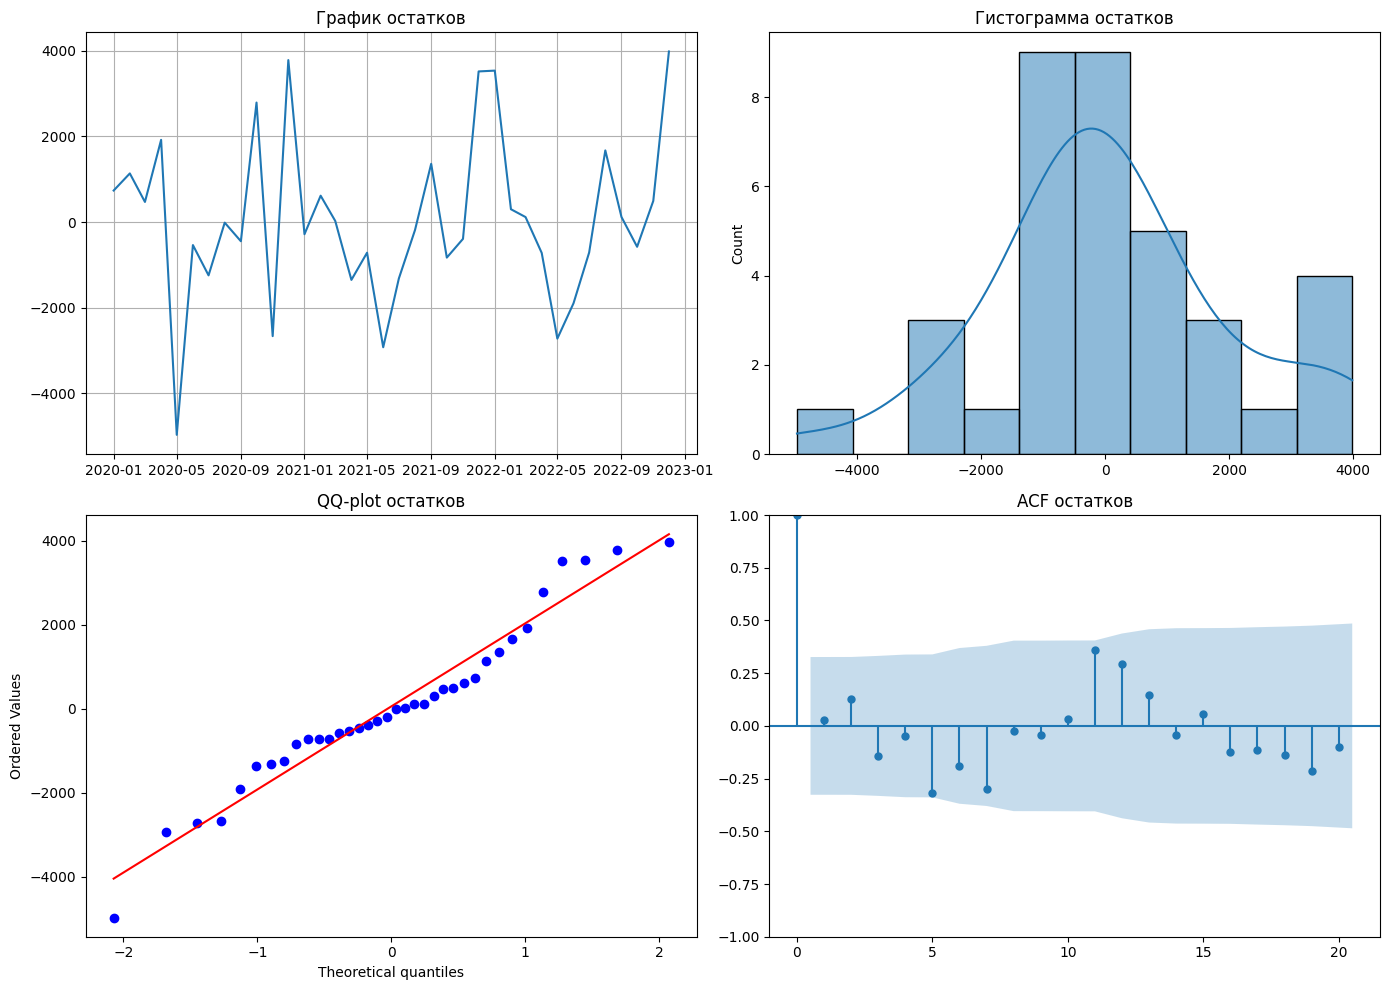

Ljung-Box test p-value: 0.2767
Shapiro-Wilk test p-value: 0.2236


In [21]:
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model_arima_2.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].grid()

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test p-value: {lb_test['lb_pvalue'].values[0]:.4f}")

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

ARIMA прошла все тесты остатков модели.

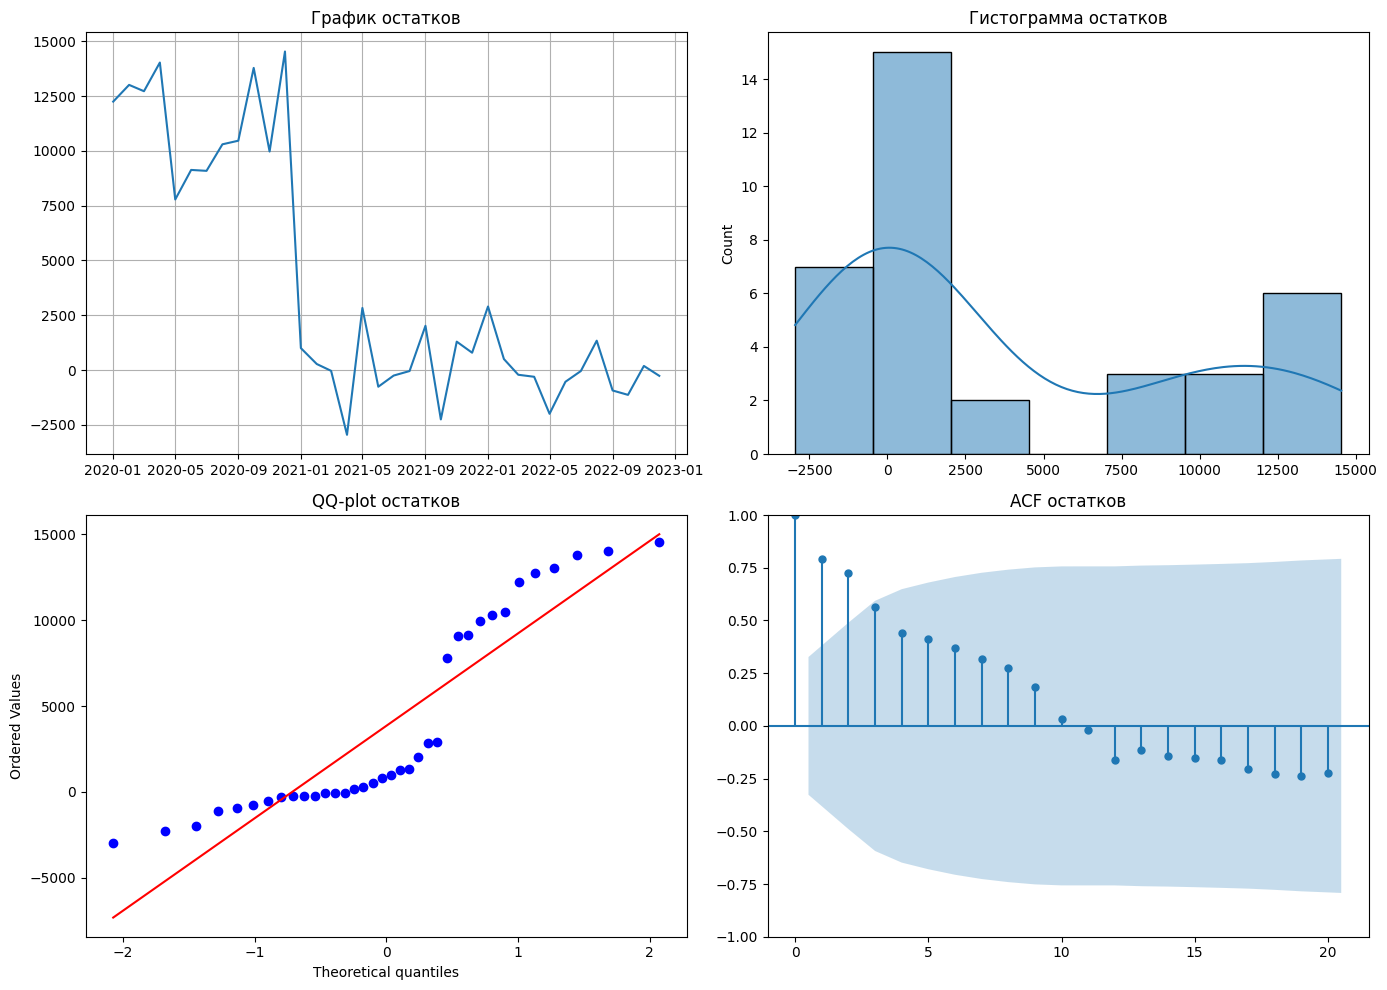

Ljung-Box test p-value: 0.0000
Shapiro-Wilk test p-value: 0.0000


In [22]:
residuals = model_sarima_2.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].grid()

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test p-value: {lb_test['lb_pvalue'].values[0]:.4f}")

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

Внезапно SARIMA (0, 0, 0)*(2, й, 0, 12) не проходит ни одного теста. Это говорит о том, что, несмотря на лучшие показатели, модель не улавливает временную структуру и просто переобучилась.

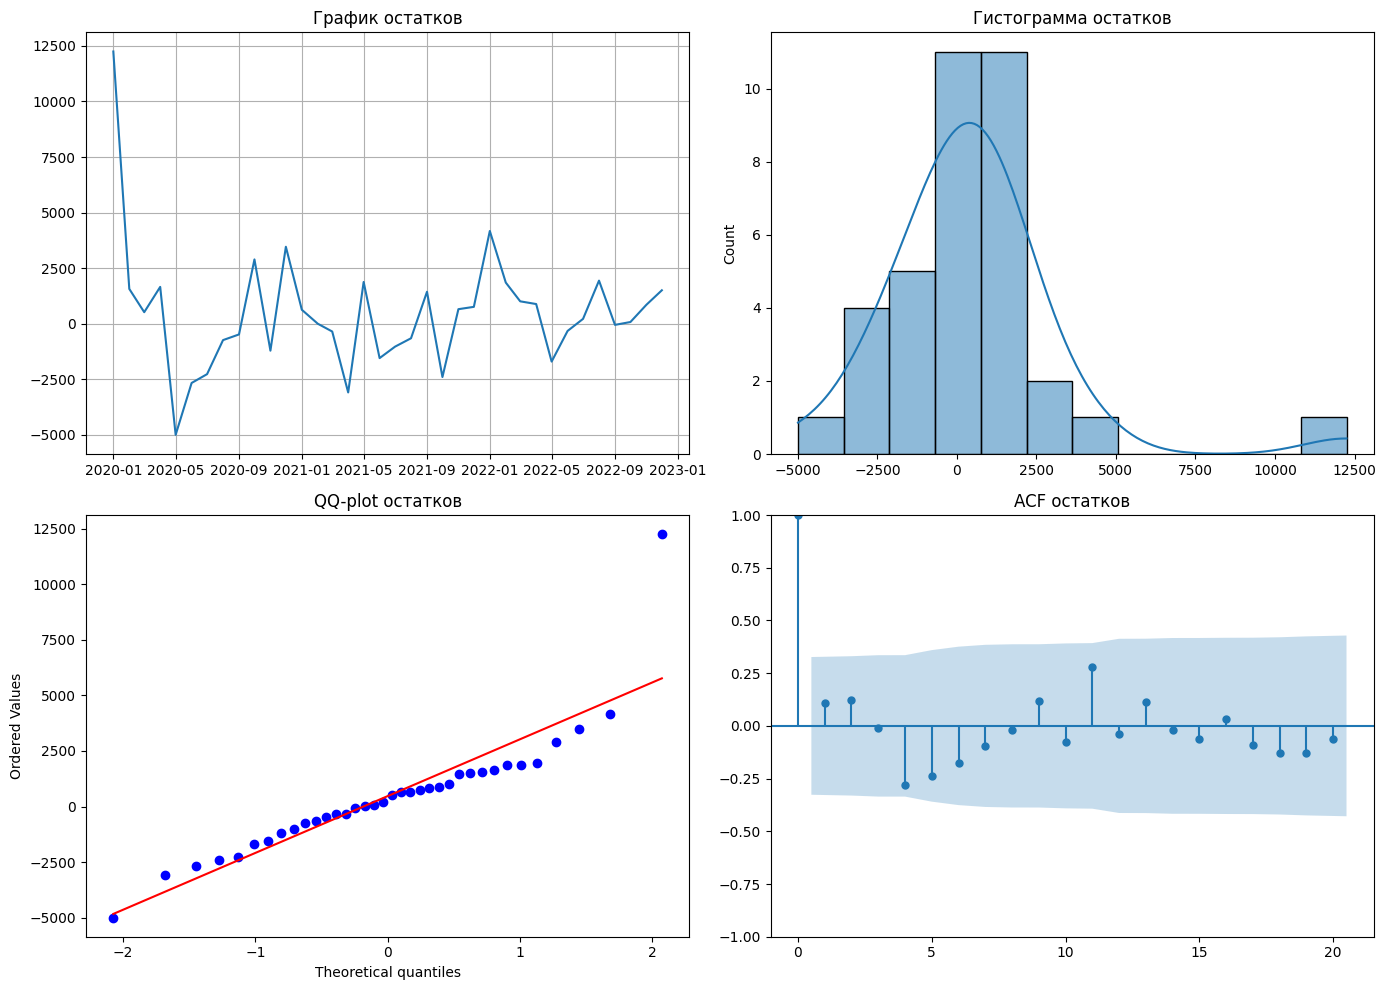

Ljung-Box test p-value: 0.4571
Shapiro-Wilk test p-value: 0.0001


In [23]:
residuals = model_sarima_1.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].grid()

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test p-value: {lb_test['lb_pvalue'].values[0]:.4f}")

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

А SARIMA (1, 0, 1)*(1, 0, 0, 12) не проходит тест Шапиро-Уилка из-за сильного выброса в первый месяц. Также, если обратить внимание на параметры ar.L1 = 1.0000 и ma.L1 = -0.9994, то они практически ликвидируют друг друга. 

Поэтому есть смысл попробовать (1, 0, 0) * (1, 0, 0, 12) и 
(0, 0, 1) * (1, 0, 0, 12)

Попробуем для решения проблемы применить к данным экзогенные переменные.

In [24]:
exog_train = train[['Promotion', 'HolidayMonth']]
exog_test = test[['Promotion', 'HolidayMonth']]

c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                         SalesAmount   No. Observations:                   36
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood                -353.652
Date:                             Fri, 09 Oct 2026   AIC                            719.304
Time:                                     02:36:01   BIC                            728.805
Sample:                                 01-01-2020   HQIC                           722.620
                                      - 12-01-2022                                         
Covariance Type:                               opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     1.142e+04   3.36e-05    3.4e+08      0.000    1.14e+04    1.14e+04
HolidayMonth  1.455e+

c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='Date', ylabel='SalesAmount'>

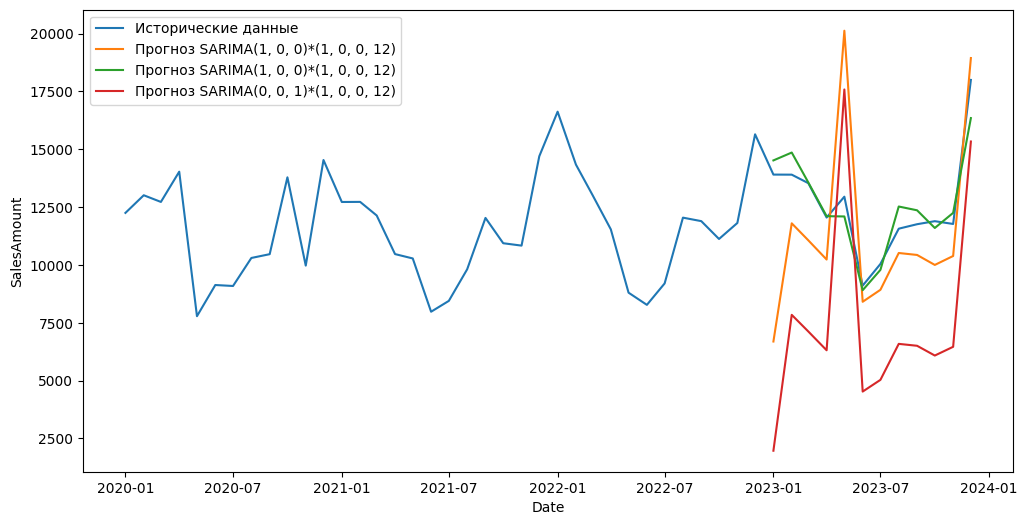

In [25]:
model_sarima_1 = SARIMAX(train['SalesAmount'],
                        exog=exog_train, 
                        order=(1, 0, 1), 
                        seasonal_order=(1, 0, 0, 12),
                        freq='MS').fit(disp=False)
model_sarima_2 = SARIMAX(train['SalesAmount'],
                        exog=exog_train,
                        order=(1, 0, 0), 
                        seasonal_order=(1, 0, 0, 12),
                        freq='MS').fit(disp=False)
model_sarima_3 = SARIMAX(train['SalesAmount'],
                        exog=exog_train,
                        order=(0, 0, 1), 
                        seasonal_order=(1, 0, 0, 12),
                        freq='MS').fit(disp=False)
print(model_sarima_1.summary())
print(model_sarima_2.summary())
print(model_sarima_3.summary())

forecast_sarima_1 = model_sarima_1.get_forecast(steps=len(test['SalesAmount']), exog=exog_test)
forecast_sarima_2 = model_sarima_2.get_forecast(steps=len(test['SalesAmount']), exog=exog_test)
forecast_sarima_3 = model_sarima_3.get_forecast(steps=len(test['SalesAmount']), exog=exog_test)


plt.figure(figsize=(12, 6))
sns.lineplot(data=df['SalesAmount'], label='Исторические данные')
sns.lineplot(data=forecast_sarima_1.predicted_mean, label='Прогноз SARIMA(1, 0, 0)*(1, 0, 0, 12)')
sns.lineplot(data=forecast_sarima_2.predicted_mean, label='Прогноз SARIMA(1, 0, 0)*(1, 0, 0, 12)')
sns.lineplot(data=forecast_sarima_3.predicted_mean, label='Прогноз SARIMA(0, 0, 1)*(1, 0, 0, 12)')

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

mse_arima = mean_squared_error(test['SalesAmount'], forecast_arima_2.predicted_mean)
r2_arima = r2_score(test['SalesAmount'], forecast_arima_2.predicted_mean)

mse_sarima_1 = mean_squared_error(test['SalesAmount'], forecast_sarima_1.predicted_mean)
r2_sarima_1 = r2_score(test['SalesAmount'], forecast_sarima_1.predicted_mean)

mse_sarima_2 = mean_squared_error(test['SalesAmount'], forecast_sarima_2.predicted_mean)
r2_sarima_2 = r2_score(test['SalesAmount'], forecast_sarima_2.predicted_mean)

mse_sarima_3 = mean_squared_error(test['SalesAmount'], forecast_sarima_3.predicted_mean)
r2_sarima_3 = r2_score(test['SalesAmount'], forecast_sarima_3.predicted_mean)

print(f"ARIMA:  MSE = {mse_arima:.2f}, R2 = {r2_arima:.4f}, AIC = {model_arima_2.aic:.2f}, BIC = {model_arima_2.bic:.2f}")
print(f"SARIMA1: MSE = {mse_sarima_1:.2f}, R2 = {r2_sarima_1:.4f}, AIC = {model_sarima_1.aic:.2f}, BIC = {model_sarima_1.bic:.2f}")
print(f"SARIMA2: MSE = {mse_sarima_2:.2f}, R2 = {r2_sarima_2:.4f}, AIC = {model_sarima_2.aic:.2f}, BIC = {model_sarima_2.bic:.2f}")
print(f"SARIMA3: MSE = {mse_sarima_3:.2f}, R2 = {r2_sarima_3:.4f}, AIC = {model_sarima_3.aic:.2f}, BIC = {model_sarima_3.bic:.2f}")

ARIMA:  MSE = 4733414.56, R2 = -0.0235, AIC = 653.07, BIC = 657.82
SARIMA1: MSE = 10694787.02, R2 = -1.3125, AIC = 719.30, BIC = 728.81
SARIMA2: MSE = 537237.72, R2 = 0.8838, AIC = 654.70, BIC = 662.62
SARIMA3: MSE = 36846307.70, R2 = -6.9670, AIC = 754.16, BIC = 762.08


На удивление, экзогеннные данные прям навредили первой и третьей моделям

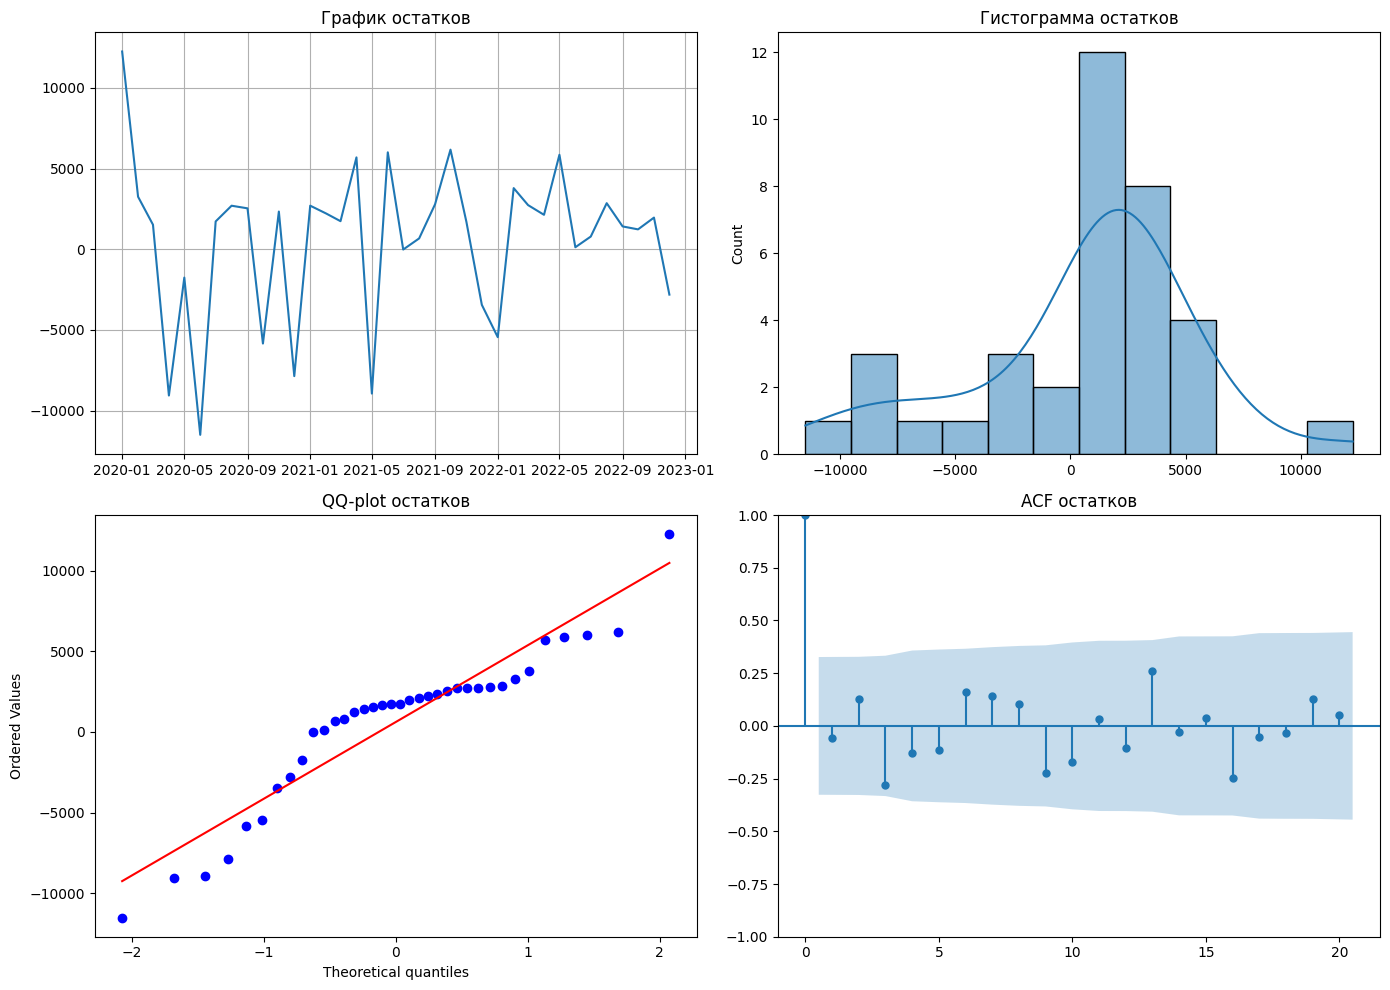

Ljung-Box test p-value: 0.2818
Shapiro-Wilk test p-value: 0.0054


In [27]:
residuals = model_sarima_1.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].grid()

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test p-value: {lb_test['lb_pvalue'].values[0]:.4f}")

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

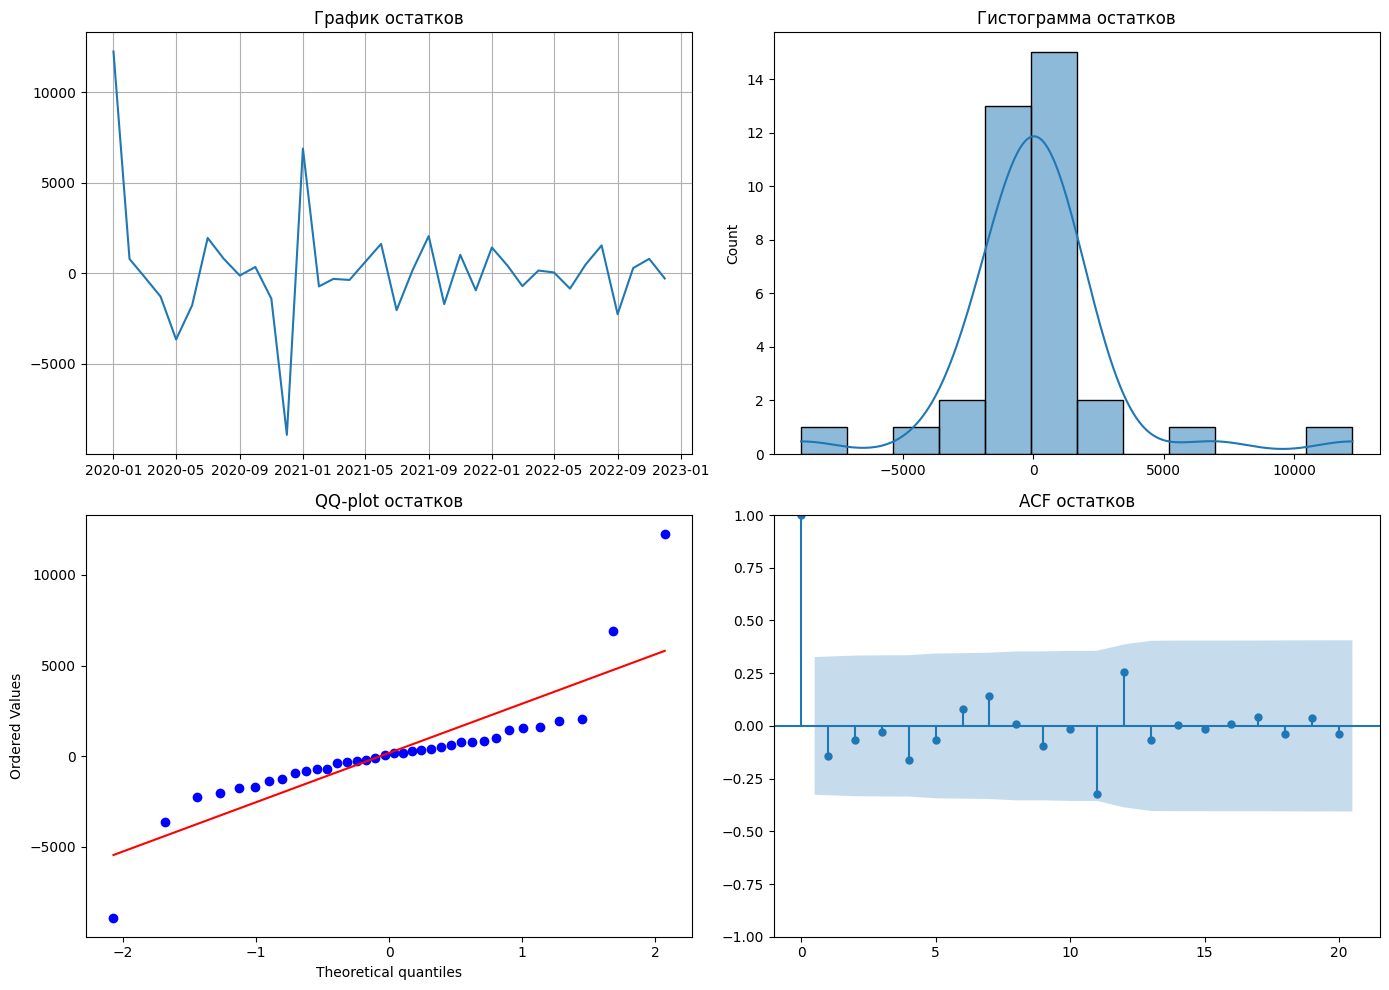

Ljung-Box test p-value: 0.9410
Shapiro-Wilk test p-value: 0.0000


In [28]:
residuals = model_sarima_2.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].grid()

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test p-value: {lb_test['lb_pvalue'].values[0]:.4f}")

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

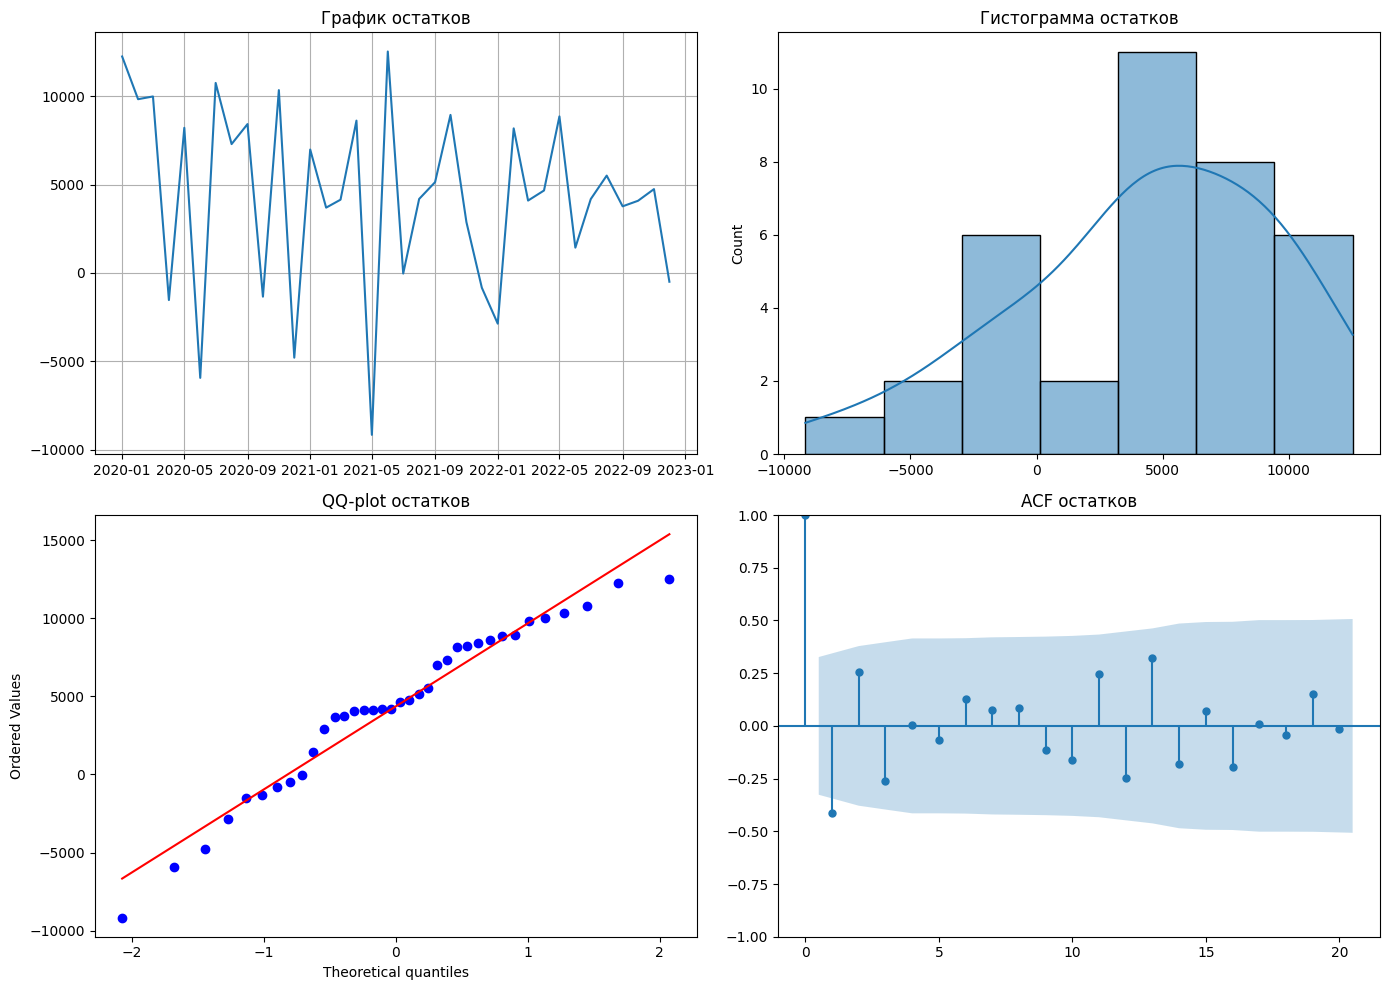

Ljung-Box test p-value: 0.1045
Shapiro-Wilk test p-value: 0.1556


In [29]:
residuals = model_sarima_3.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].grid()

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test p-value: {lb_test['lb_pvalue'].values[0]:.4f}")

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

По итогу тесты смогла пройти только третья модель, но ее результаты явно не впечатляют

Из-за того, что HolidayMonth просто отмечает декабри, то эта метка может сильно коррелировать с периодом и мешать модели, потому попробуем ради интереса без нее.

In [30]:
exog_train = train['Promotion']
exog_test = test['Promotion']

c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


                                      SARIMAX Results                                      
Dep. Variable:                         SalesAmount   No. Observations:                   36
Model:             SARIMAX(0, 0, 1)x(1, 0, [], 12)   Log Likelihood                -360.334
Date:                             Fri, 09 Oct 2026   AIC                            728.669
Time:                                     02:36:52   BIC                            735.003
Sample:                                 01-01-2020   HQIC                           730.879
                                      - 12-01-2022                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Promotion   9526.9425   1709.686      5.572      0.000    6176.020    1.29e+04
ma.L1          0.2515      

<Axes: xlabel='Date', ylabel='SalesAmount'>

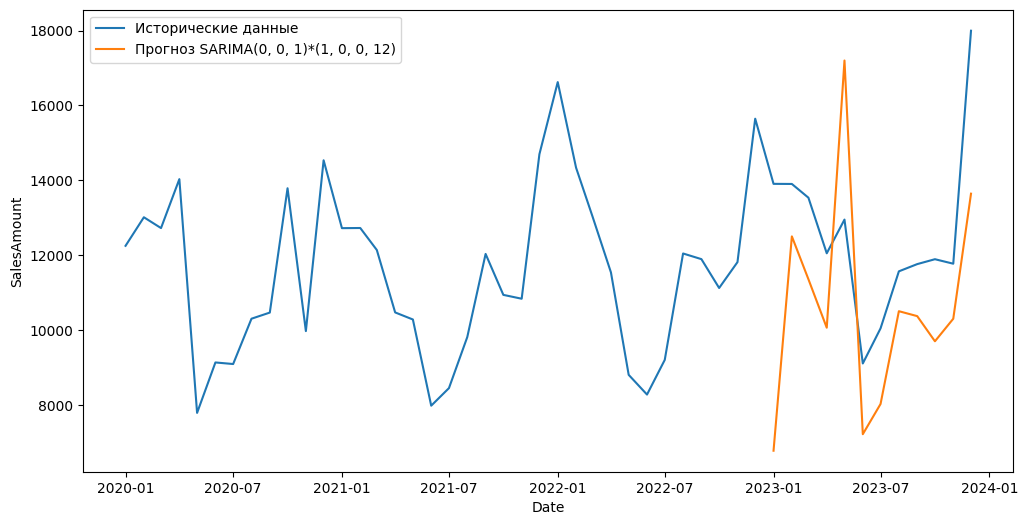

In [ ]:
model_sarima_1 = SARIMAX(train['SalesAmount'],
                        exog=exog_train, 
                        order=(1, 0, 1), 
                        seasonal_order=(1, 0, 0, 12),
                        freq='MS').fit(disp=False)
model_sarima_2 = SARIMAX(train['SalesAmount'],
                        exog=exog_train,
                        order=(0, 0, 0), 
                        seasonal_order=(2, 1, 0, 12),
                        freq='MS').fit(disp=False)
print(model_sarima_1.summary())
print(model_sarima_2.summary())

forecast_sarima_1 = model_sarima_1.get_forecast(steps=len(test['SalesAmount']), exog=exog_test)
forecast_sarima_2 = model_sarima_2.get_forecast(steps=len(test['SalesAmount']), exog=exog_test)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df['SalesAmount'], label='Исторические данные')
sns.lineplot(data=forecast_sarima_1.predicted_mean, label='Прогноз SARIMA(1, 0, 0)*(1, 0, 0, 12)')
sns.lineplot(data=forecast_sarima_2.predicted_mean, label='Прогноз SARIMA(0, 0, 0)*(2, 1, 0, 12)')

В этот раз Promotion смог повлиять только на вторую модель

In [32]:
from sklearn.metrics import mean_squared_error, r2_score

mse_arima = mean_squared_error(test['SalesAmount'], forecast_arima_2.predicted_mean)
r2_arima = r2_score(test['SalesAmount'], forecast_arima_2.predicted_mean)

mse_sarima_1 = mean_squared_error(test['SalesAmount'], forecast_sarima_1.predicted_mean)
r2_sarima_1 = r2_score(test['SalesAmount'], forecast_sarima_1.predicted_mean)

mse_sarima_2 = mean_squared_error(test['SalesAmount'], forecast_sarima_2.predicted_mean)
r2_sarima_2 = r2_score(test['SalesAmount'], forecast_sarima_2.predicted_mean)

mse_sarima_3 = mean_squared_error(test['SalesAmount'], forecast_sarima_3.predicted_mean)
r2_sarima_3 = r2_score(test['SalesAmount'], forecast_sarima_3.predicted_mean)

print(f"ARIMA:  MSE = {mse_arima:.2f}, R2 = {r2_arima:.4f}, AIC = {model_arima_2.aic:.2f}, BIC = {model_arima_2.bic:.2f}")
print(f"SARIMA1: MSE = {mse_sarima_1:.2f}, R2 = {r2_sarima_1:.4f}, AIC = {model_sarima_1.aic:.2f}, BIC = {model_sarima_1.bic:.2f}")
print(f"SARIMA2: MSE = {mse_sarima_2:.2f}, R2 = {r2_sarima_2:.4f}, AIC = {model_sarima_2.aic:.2f}, BIC = {model_sarima_2.bic:.2f}")
print(f"SARIMA3: MSE = {mse_sarima_3:.2f}, R2 = {r2_sarima_3:.4f}, AIC = {model_sarima_3.aic:.2f}, BIC = {model_sarima_3.bic:.2f}")

ARIMA:  MSE = 4733414.56, R2 = -0.0235, AIC = 653.07, BIC = 657.82
SARIMA1: MSE = 661300.31, R2 = 0.8570, AIC = 643.73, BIC = 651.65
SARIMA2: MSE = 17823479.26, R2 = -2.8538, AIC = 684.75, BIC = 691.08
SARIMA3: MSE = 9687949.17, R2 = -1.0948, AIC = 728.67, BIC = 735.00


Первой модели это реально помогло, а вот остальным сделало только хуже

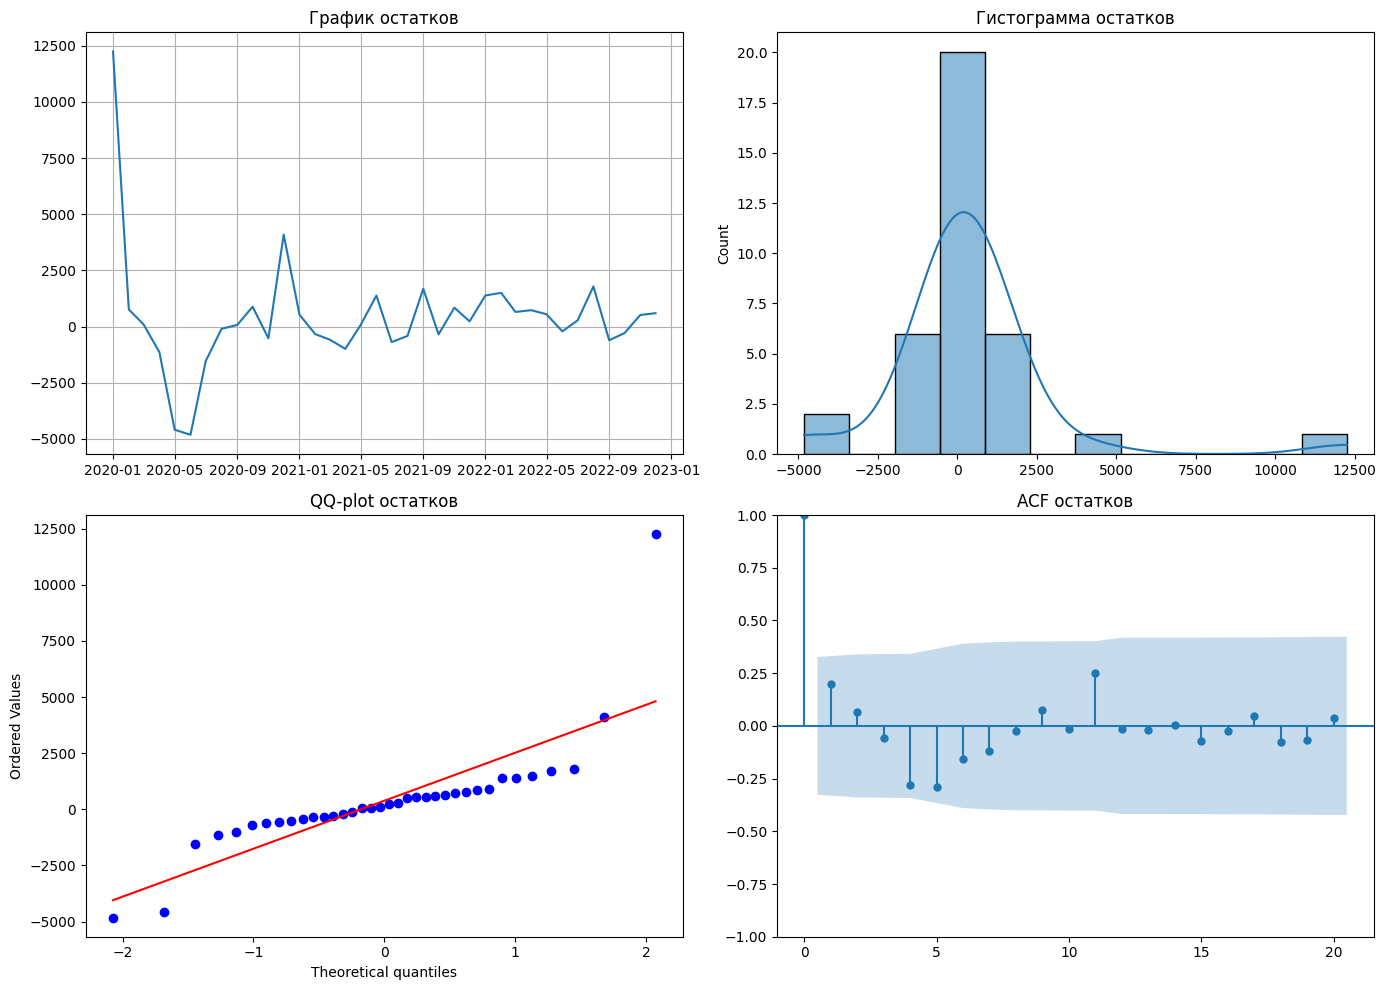

Ljung-Box test p-value: 0.3465
Shapiro-Wilk test p-value: 0.0000


In [33]:
residuals = model_sarima_1.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].grid()

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test p-value: {lb_test['lb_pvalue'].values[0]:.4f}")

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

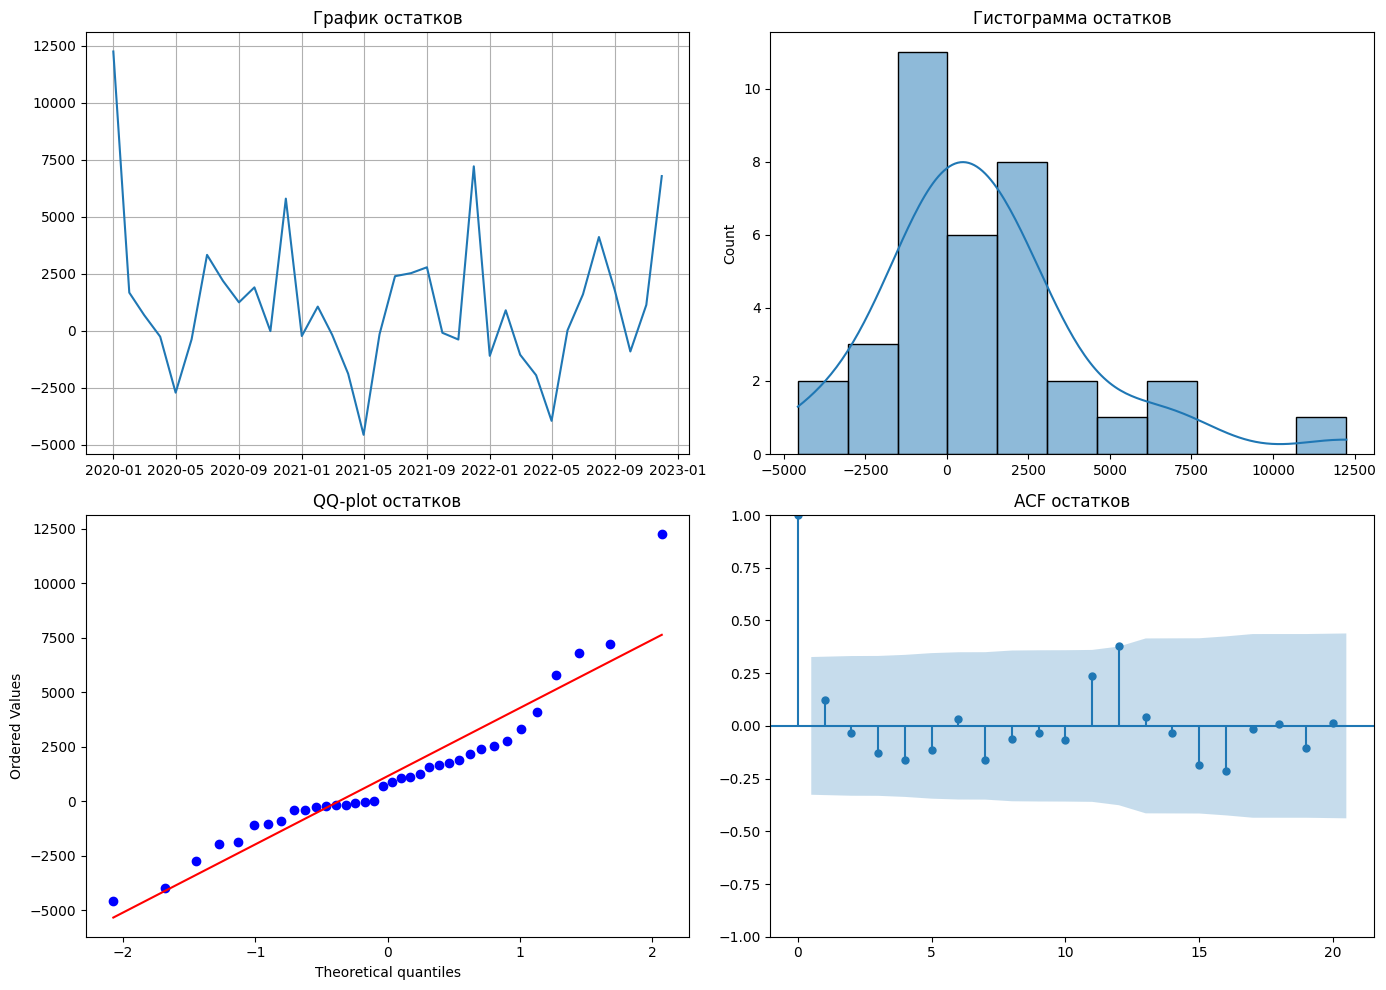

Ljung-Box test p-value: 0.9060
Shapiro-Wilk test p-value: 0.0054


In [34]:
residuals = model_sarima_2.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].grid()

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test p-value: {lb_test['lb_pvalue'].values[0]:.4f}")

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

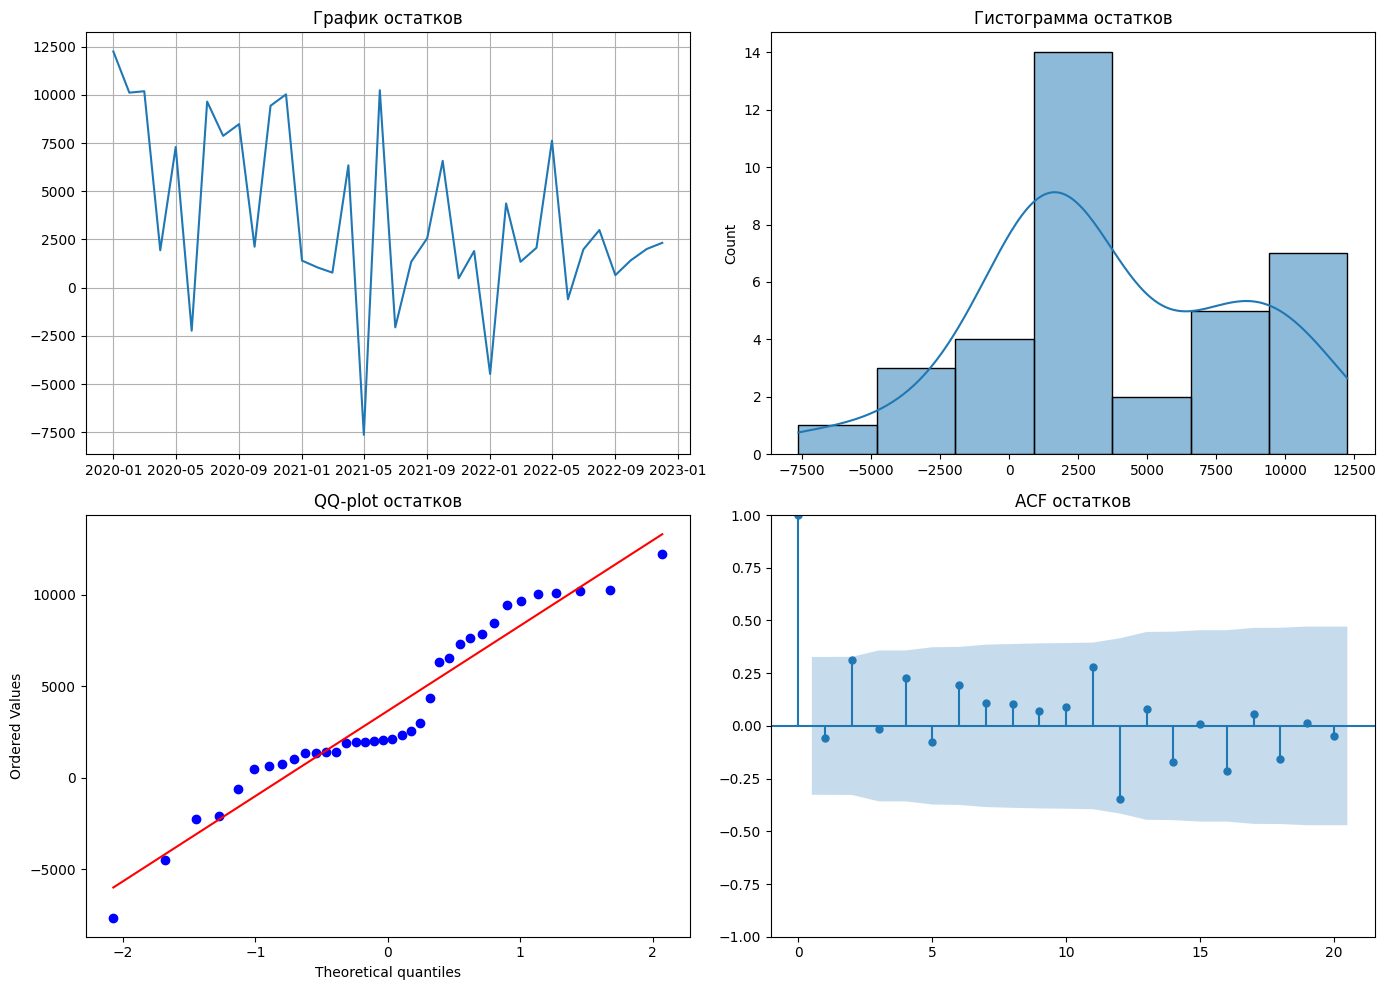

Ljung-Box test p-value: 0.4388
Shapiro-Wilk test p-value: 0.0611


In [35]:
residuals = model_sarima_3.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].grid()

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test p-value: {lb_test['lb_pvalue'].values[0]:.4f}")

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

И снова тесты смогла пройти только третья модель, да и то на грани

# Итоговый результат

После достаточно долгого времени подбора и анализа результатов моделирования получилось подобрать наиболее оптимальную структуру:

c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -305.469
Date:                Fri, 09 Oct 2026   AIC                            622.938
Time:                        03:57:42   BIC                            632.439
Sample:                    01-01-2020   HQIC                           626.254
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.094e+04    606.486     18.031      0.000    9746.902    1.21e+04
Promotion     2812.2017    232.002     12.121      0.000    2357.486    3266.918
HolidayMonth  3549.1694    188.538     18.82

c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


<Axes: xlabel='Date', ylabel='SalesAmount'>

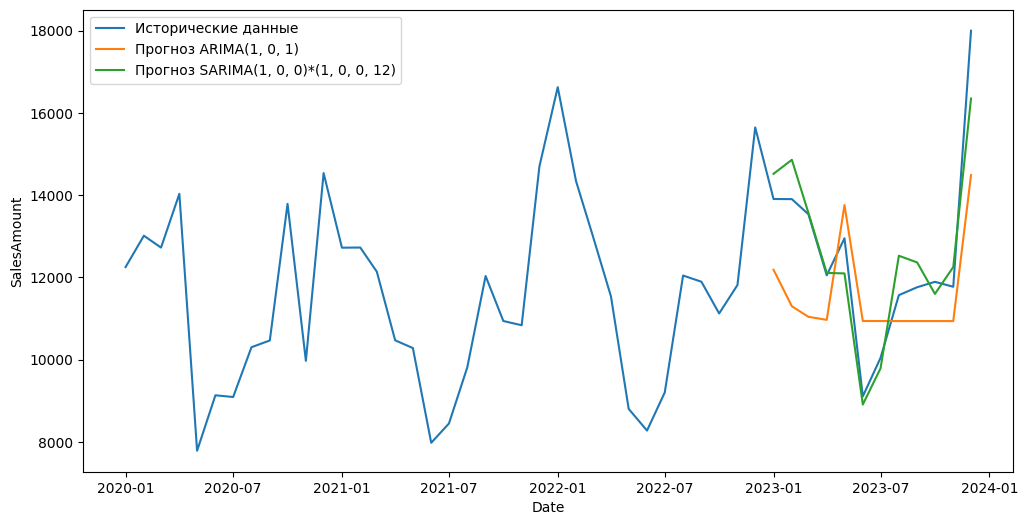

In [184]:
exog_train = train[['Promotion', 'HolidayMonth']]
exog_test = test[['Promotion', 'HolidayMonth']]

model_arima = ARIMA(train['SalesAmount'],
                        exog=exog_train,
                        order=(1, 0, 1), 
                        freq='MS').fit()
model_sarima = SARIMAX(train['SalesAmount'],
                        exog=exog_train,
                        order=(1, 0, 0), 
                        seasonal_order=(1, 0, 0, 12),
                        freq='MS').fit(cov_type='oim', disp=False)

print(model_arima.summary())
print(model_sarima.summary())

forecast_arima = model_arima.get_forecast(steps=len(test['SalesAmount']), exog=exog_test)
forecast_sarima = model_sarima.get_forecast(steps=len(test['SalesAmount']), exog=exog_test)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df['SalesAmount'], label='Исторические данные')
sns.lineplot(data=forecast_arima.predicted_mean, label='Прогноз ARIMA(1, 0, 1)')
sns.lineplot(data=forecast_sarima.predicted_mean, label='Прогноз SARIMA(1, 0, 0)*(1, 0, 0, 12)')

In [181]:
from sklearn.metrics import mean_squared_error, r2_score

mse_arima = mean_squared_error(test['SalesAmount'], forecast_arima.predicted_mean)
r2_arima = r2_score(test['SalesAmount'], forecast_arima.predicted_mean)

mse_sarima = mean_squared_error(test['SalesAmount'], forecast_sarima.predicted_mean)
r2_sarima = r2_score(test['SalesAmount'], forecast_sarima.predicted_mean)

print(f"ARIMA:  MSE = {mse_arima:.2f}, R2 = {r2_arima:.4f}, AIC = {model_arima.aic:.2f}, BIC = {model_arima.bic:.2f}")
print(f"SARIMA1: MSE = {mse_sarima:.2f}, R2 = {r2_sarima:.4f}, AIC = {model_sarima.aic:.2f}, BIC = {model_sarima.bic:.2f}")

ARIMA:  MSE = 3080954.02, R2 = 0.3338, AIC = 622.94, BIC = 632.44
SARIMA1: MSE = 537237.72, R2 = 0.8838, AIC = 654.70, BIC = 662.62


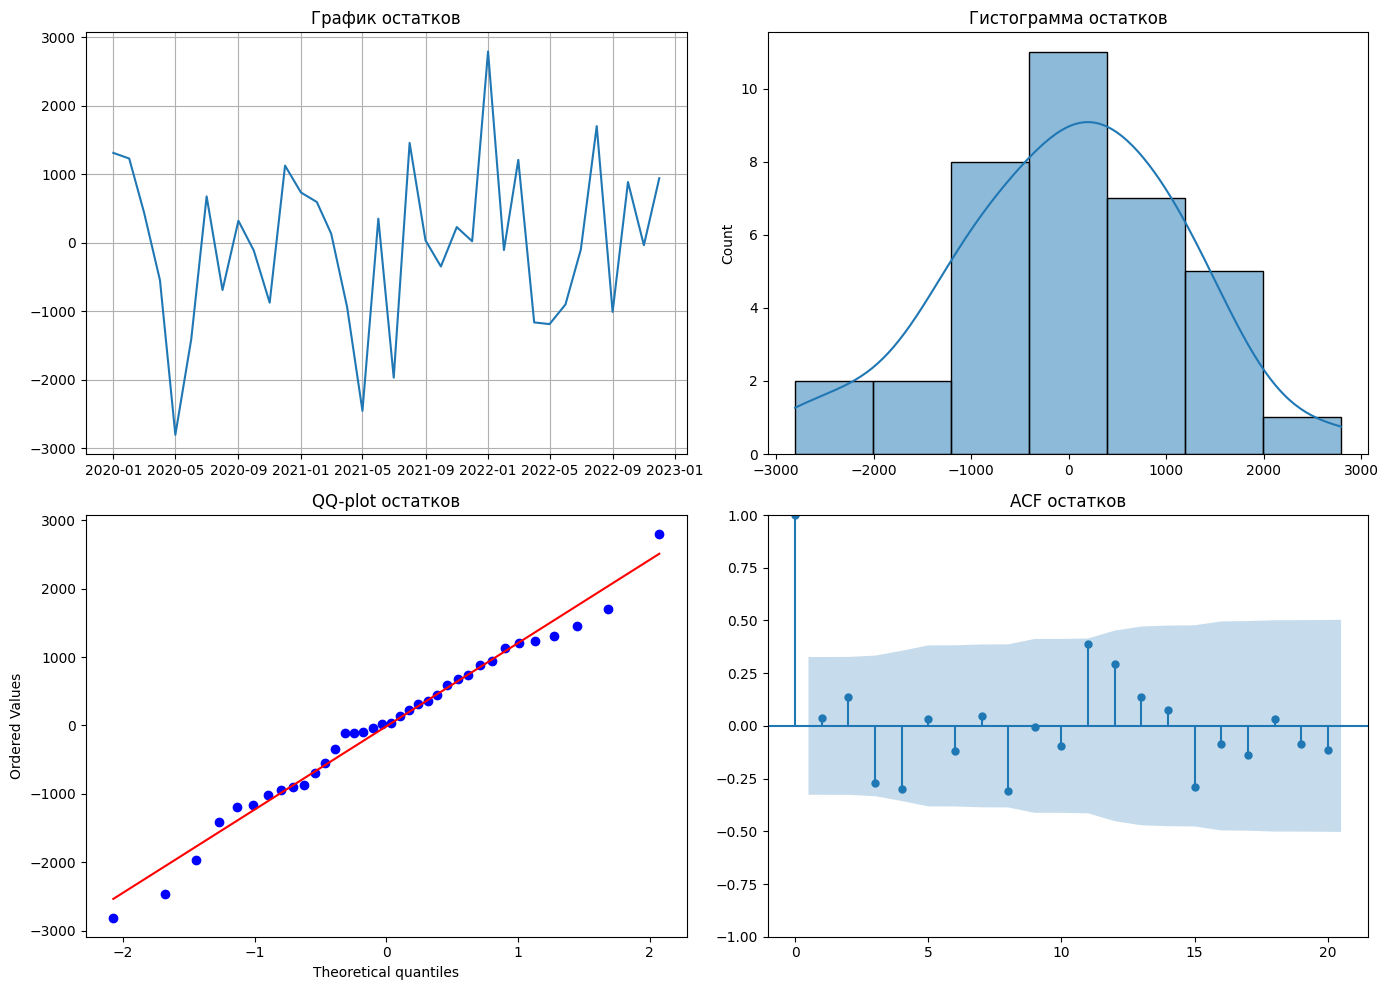

Ljung-Box test p-value: 0.1892
Shapiro-Wilk test p-value: 0.9259


In [177]:
residuals = model_arima.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].grid()

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test p-value: {lb_test['lb_pvalue'].values[0]:.4f}")

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

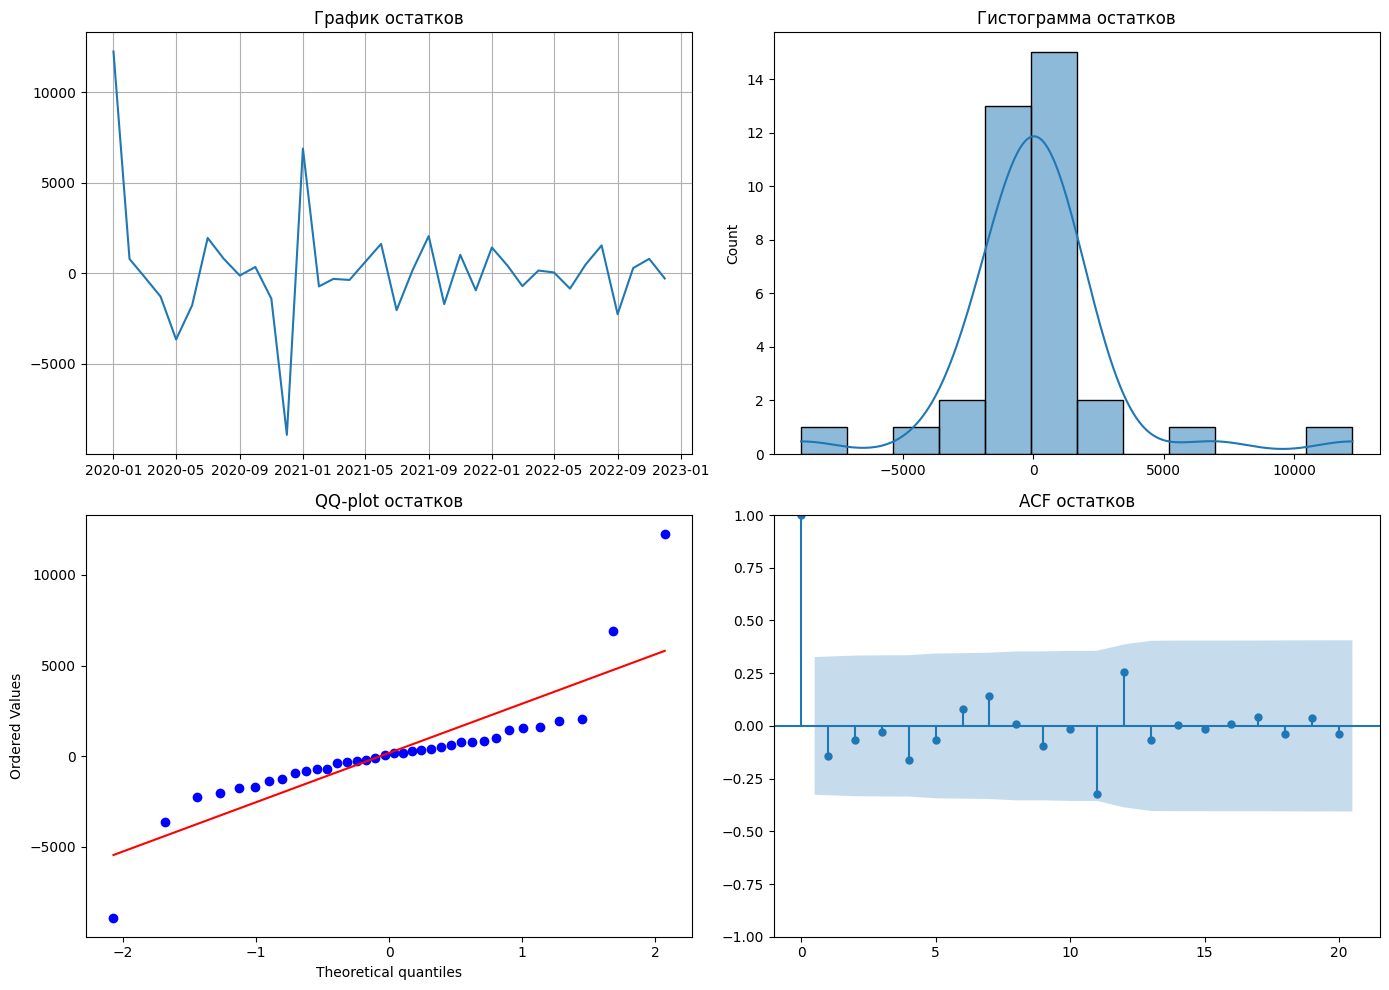

Ljung-Box test p-value: 0.9410
Shapiro-Wilk test p-value: 0.0000


In [178]:
residuals = model_sarima.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].grid()

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Ljung-Box test p-value: {lb_test['lb_pvalue'].values[0]:.4f}")

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue:.4f}")

Тест Шапиро-Уилка так и не удалось пройти, но, судя по всему, он очень чувствителен для таких мальньних выборок к выбросам. В тоже время тест Жарке-Бера спокойно проходится. Также интересен момент с тестом на автокоррелированность: на 10 лагах он спокойно проходится, а в summary он дает p-value=0. Тест на гетероскедастичность пройден, так что тут проблем нет.

Поскольку данные имеют явно выраженный сезонный тренд, то выбор SARIMAX очевиден, но пришлось постараться, чтобы подобрать параметры и настройки к модели.